In [10]:
import jax
import jax.numpy as jnp
import numpyro 
import numpyro.distributions as dist

from quantbayes.bnn.layers.custom_jvp import spectral_circulant_matmul, SpectralCirculantLayer

# ---------------------------------------------------------------------------
# helpers
# ---------------------------------------------------------------------------
def upsample_bilinear(grid, H_pad, W_pad):
    """Bilinearly up‑sample a coarse grid (Bilinear resize, no grad issues)."""
    gh, gw = grid.shape
    # Normalised coordinates in [0,1]
    y = jnp.linspace(0.0, 1.0, H_pad)
    x = jnp.linspace(0.0, 1.0, W_pad)
    yy, xx = jnp.meshgrid(y, x, indexing="ij")
    # Map to coarse‑grid indices
    yy = yy * (gh - 1)
    xx = xx * (gw - 1)
    y0, x0 = jnp.floor(yy).astype(int), jnp.floor(xx).astype(int)
    y1, x1 = jnp.clip(y0 + 1, 0, gh - 1), jnp.clip(x0 + 1, 0, gw - 1)
    wy, wx = yy - y0, xx - x0
    v00, v01 = grid[y0, x0], grid[y0, x1]
    v10, v11 = grid[y1, x0], grid[y1, x1]
    return (
        (1 - wy) * ((1 - wx) * v00 + wx * v01)
        + wy * ((1 - wx) * v10 + wx * v11)
    )


# ---------------------------------------------------------------------------
# 1‑D  (non‑stationary exponent α[k])
# ---------------------------------------------------------------------------
class NonStatSpectralCirculantLayer(SpectralCirculantLayer):
    def __init__(self, in_features, padded_dim=None,
                 alpha_global=1.0, alpha_prior=dist.HalfNormal(1.0),
                 K=None, name="ns_spectral_circ", prior_fn=None):
        super().__init__(in_features, padded_dim, alpha=None,
                         alpha_prior=alpha_prior, K=K,
                         name=name, prior_fn=prior_fn)
        self.alpha_global = alpha_global

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # 1) Sample per-frequency Δα
        delta_alpha = numpyro.sample(
            f"{self.name}_delta_alpha",
            self.alpha_prior.expand([self.k_half]).to_event(1)
        )
        # 2) clamp α into [0.1, 5.0]
        alpha_vec = jnp.clip(self.alpha_global + delta_alpha, 0.1, 5.0)

        # 3) PSD std
        freq_idx = jnp.arange(self.k_half)
        prior_std = 1.0 / jnp.sqrt(1.0 + freq_idx**alpha_vec)

        # 4) rest as before
        active_idx = jnp.arange(self.K)
        real_hp = numpyro.sample(
            f"{self.name}_real",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1)
        )
        imag_hp = numpyro.sample(
            f"{self.name}_imag",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1)
        )

        full_real = jnp.zeros((self.k_half,));  full_real = full_real.at[active_idx].set(real_hp)
        full_imag = jnp.zeros((self.k_half,));  full_imag = full_imag.at[active_idx].set(imag_hp)

        # DC & Nyquist real
        full_imag = full_imag.at[0].set(0.0)
        if (self.padded_dim % 2 == 0) and (self.k_half>1):
            full_imag = full_imag.at[-1].set(0.0)

        half_complex = full_real + 1j*full_imag
        if (self.padded_dim%2==0) and (self.k_half>1):
            nyq = half_complex[-1].real[None]
            fft_full = jnp.concatenate([
                half_complex[:-1], nyq,
                jnp.conj(half_complex[1:-1])[::-1]
            ])
        else:
            fft_full = jnp.concatenate([
                half_complex, jnp.conj(half_complex[1:])[::-1]
            ])

        self._last_fft_full = jax.lax.stop_gradient(fft_full)
        bias = numpyro.sample(
            f"{self.name}_bias_spectral",
            dist.Normal(0.,1.).expand([self.padded_dim]).to_event(1)
        )
        return spectral_circulant_matmul(x, fft_full) + bias



In [11]:
from quantbayes.bnn.layers.custom_jvp import spectral_circulant_conv2d, _enforce_hermitian, SpectralPowerLawConv2d

# ---------------------------------------------------------------------------
# 2‑D  (coarse α‑map -> upsample -> per‑freq std)
# ---------------------------------------------------------------------------
class NonStatSpectralConv2d(SpectralPowerLawConv2d):
    def __init__(self, H_in, W_in, H_pad=None, W_pad=None,
                 alpha_global=1.0, alpha_coarse_shape=(8,8),
                 alpha_prior=dist.HalfNormal(1.0),
                 name="ns_spec_pw", prior_fn=None):
        super().__init__(H_in, W_in, H_pad, W_pad,
                         alpha=None, alpha_prior=alpha_prior,
                         name=name, prior_fn=prior_fn)
        self.alpha_global    = alpha_global
        self.alpha_coarse_shape = alpha_coarse_shape

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        gh, gw = self.alpha_coarse_shape
        # 1) sample coarse Δα-map
        delta_alpha_coarse = numpyro.sample(
            f"{self.name}_delta_alpha_map",
            self.alpha_prior
              .expand(self.alpha_coarse_shape)
              .to_event(2)
        )
        # 2) upsample & clamp
        delta_alpha_full = upsample_bilinear(delta_alpha_coarse,
                                             self.H_pad, self.W_pad)
        alpha_full = jnp.clip(self.alpha_global + delta_alpha_full,
                              0.1, 5.0)

        # 3) radial grid & PSD std
        u = jnp.fft.fftfreq(self.H_pad)*self.H_pad
        v = jnp.fft.fftfreq(self.W_pad)*self.W_pad
        U,V = jnp.meshgrid(u,v, indexing="ij")
        R = jnp.sqrt(U**2+V**2)
        std = 1.0/jnp.sqrt(1.0+R**alpha_full)

        # 4) sample real/imag & enforce Hermitian
        real = numpyro.sample(f"{self.name}_real",
                              self.prior_fn(std).to_event(2))
        imag = numpyro.sample(f"{self.name}_imag",
                              self.prior_fn(std).to_event(2))
        fft2d = _enforce_hermitian(real+1j*imag)

        bias = numpyro.sample(
            f"{self.name}_bias",
            dist.Normal(0.,1.)
              .expand([self.H_pad,self.W_pad]).to_event(2)
        )
        return spectral_circulant_conv2d(x, fft2d) + bias


In [35]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, init_to_feasible
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoGuideList, AutoNormal

from quantbayes.bnn.guide import LowRankNonStatFFTGuide

# -------------------------------------------------------------------------
# 1) 2D Non‑Stationary Conv model
# -------------------------------------------------------------------------
def conv_model(X, y=None):
    # X: (N,28,28)
    conv = NonStatSpectralConv2d(
        H_in=28, W_in=28,
        H_pad=28, W_pad=28,
        alpha_global=1.0,
        alpha_coarse_shape=(8, 8),
        alpha_prior=dist.HalfNormal(1.0),
        name="mix",
        prior_fn=None,            # or whatever you had before
    )
    h = conv(X)                   # (N,28,28)
    h = h.reshape(h.shape[0], -1) # (N, 784)
    W = numpyro.sample("W", dist.Normal(0, 1)
                       .expand([h.shape[-1], 1]).to_event(2))
    b = numpyro.sample("b", dist.Normal(0, 1)
                       .expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.matmul(h, W) + b)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

# -------------------------------------------------------------------------
# 2) 1D Non‑Stationary Circulant model
# -------------------------------------------------------------------------
def circ1d_model(X, y=None):
    # X: (N, D)
    D = X.shape[1]
    circ = NonStatSpectralCirculantLayer(
        in_features=D,
        padded_dim=D,
        alpha_global=1.0,
        alpha_prior=dist.HalfNormal(1.0),
        K=None,
        name="mix1d",
        prior_fn=None,            # match your original
    )
    h = circ(X)                  # (N, D)
    W = numpyro.sample("W1d", dist.Normal(0, 1)
                       .expand([D, 1]).to_event(2))
    b = numpyro.sample("b1d", dist.Normal(0, 1)
                       .expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.matmul(h, W) + b)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs1d", dist.Bernoulli(logits=logits), obs=y)

# -------------------------------------------------------------------------
# Shared SVI runner
# -------------------------------------------------------------------------
def run_test(model, guide, X, y, n_steps=200, lr=1e-2):
    rng_key = jax.random.PRNGKey(0)
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    svi_state = svi.init(rng_key, X, y)
    losses = []
    for i in range(n_steps):
        svi_state, loss = svi.update(svi_state, X, y)
        if i % 50 == 0:
            print(f"step {i:<3d} ELBO loss = {loss:.3f}")
        losses.append(loss)
    params = svi.get_params(svi_state)
    print("final loss:", loss)
    return params, losses

# -------------------------------------------------------------------------
# 2D conv test setup
# -------------------------------------------------------------------------
N = 64
X_conv = jax.random.normal(jax.random.PRNGKey(1), (N, 28, 28))
y_conv = (jnp.sum(X_conv, axis=(1,2)) > 0).astype(int)

conv_guide = AutoGuideList(conv_model)
conv_guide.append(
    LowRankNonStatFFTGuide(
        conv_model,
        prefix="mix",
        H_pad=28,
        W_pad=28,
        alpha_coarse_shape=(8, 8),
        rank=4,
        jitter=1e-5,
    )
)
conv_guide.append(
    AutoNormal(
        numpyro.handlers.block(conv_model, hide=["mix_real","mix_imag","mix_delta_alpha_map"]),
        init_loc_fn=init_to_feasible,
    )
)

print("\n=== Testing 2D Non‑Stationary Conv ===")
params_conv, losses_conv = run_test(conv_model, conv_guide, X_conv, y_conv)

# -------------------------------------------------------------------------
# 1D circulant test setup
# -------------------------------------------------------------------------
D = 32
X1d = jax.random.normal(jax.random.PRNGKey(2), (N, D))
y1d = (jnp.sum(X1d, axis=1) > 0).astype(int)

circ1d_guide = AutoGuideList(circ1d_model)
circ1d_guide.append(
    LowRankNonStat1DGuide(
        circ1d_model,
        prefix="mix1d",
        H_pad=D,
        W_pad=D,
        rank=4,
        jitter=1e-5,
    )
)
circ1d_guide.append(
    AutoNormal(
        numpyro.handlers.block(
            circ1d_model,
            hide=["mix1d_real", "mix1d_imag", "mix1d_delta_alpha"]
        ),
        init_loc_fn=init_to_feasible,
    )
)

print("\n=== Testing 1D Non‑Stationary Circulant ===")
params_1d, losses = run_test(circ1d_model, circ1d_guide, X1d, y1d)



=== Testing 2D Non‑Stationary Conv ===
step 0   ELBO loss = 2980.002
step 50  ELBO loss = 2253.629
step 100 ELBO loss = 1579.378
step 150 ELBO loss = 915.193
final loss: 594.06055

=== Testing 1D Non‑Stationary Circulant ===
step 0   ELBO loss = 166.711
step 50  ELBO loss = 136.206
step 100 ELBO loss = 92.526
step 150 ELBO loss = 64.441
final loss: 57.278133


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# -- re‑define these if you haven’t already in this notebook --
def upsample_bilinear_np(grid, H_pad, W_pad):
    gh, gw = grid.shape
    ys = np.linspace(0, gh - 1, H_pad)
    xs = np.linspace(0, gw - 1, W_pad)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')
    y0 = yy.astype(int);  x0 = xx.astype(int)
    y1 = np.clip(y0+1, 0, gh-1);  x1 = np.clip(x0+1, 0, gw-1)
    wy = yy - y0;  wx = xx - x0
    v00 = grid[y0, x0];  v01 = grid[y0, x1]
    v10 = grid[y1, x0];  v11 = grid[y1, x1]
    return (1-wy)*((1-wx)*v00 + wx*v01) + wy*((1-wx)*v10 + wx*v11)

def extract_delta_map_from_loc_np(params, prefix, H_pad, W_pad, gh, gw):
    W_half = W_pad//2 + 1
    M = H_pad * W_half
    G = gh * gw
    loc = np.asarray(params[f"{prefix}_joint_loc"])
    delta_flat = loc[2*M : 2*M + G]
    return delta_flat.reshape(gh, gw)

# 1) Full‑res α heatmap
def plot_alpha_heatmap_np(params, prefix, H_pad, W_pad, gh, gw, alpha_global=1.0):
    delta_coarse = extract_delta_map_from_loc_np(params, prefix, H_pad, W_pad, gh, gw)
    full_delta  = upsample_bilinear_np(delta_coarse, H_pad, W_pad)
    full_alpha  = alpha_global + full_delta
    plt.figure(figsize=(4,4))
    plt.imshow(full_alpha, origin='lower', aspect='auto', cmap='inferno')
    plt.colorbar(label='α(u,v)')
    plt.title(f'Inferred α heatmap (“{prefix}”)')
    plt.xlabel('Frequency v')
    plt.ylabel('Frequency u')
    plt.tight_layout()
    plt.show()

# 2) Singular value spectrum
def get_singular_values_np(params, prefix):
    V = np.asarray(params[f"{prefix}_joint_V"])   # (dim, rank)
    return np.linalg.svd(V, compute_uv=False)

def plot_singular_spectra_np(svs_dict):
    plt.figure(figsize=(5,3))
    for rank, sv in sorted(svs_dict.items()):
        plt.plot(sv, label=f'r={rank}')
    plt.title('Singular values of V by rank')
    plt.xlabel('Component index')
    plt.ylabel('σ')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3) ELBO vs rank
def plot_elbo_vs_rank_np(ranks, losses):
    plt.figure(figsize=(4,3))
    plt.plot(ranks, losses, 'o-')
    plt.title('Final ELBO vs guide rank')
    plt.xlabel('Rank')
    plt.ylabel('ELBO loss')
    plt.tight_layout()
    plt.show()


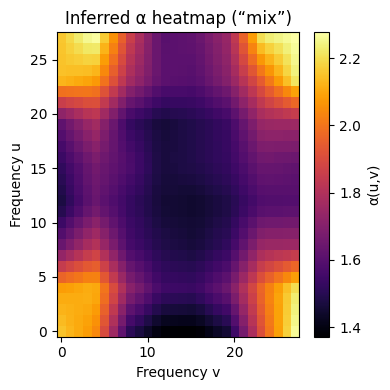

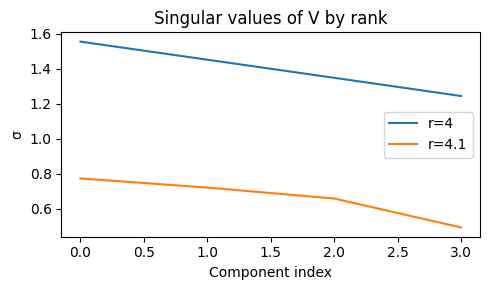

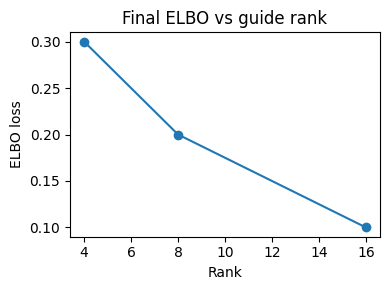

In [38]:
# -- α heatmap for the 2D conv layer --
plot_alpha_heatmap_np(
    params_conv, 
    prefix="mix", 
    H_pad=28, W_pad=28, 
    gh=8, gw=8,
    alpha_global=1.0
)

# -- singular spectrum at rank=4 for both layers --
sv_conv  = get_singular_values_np(params_conv, "mix")
sv_circ1 = get_singular_values_np(params_1d,  "mix1d")
plot_singular_spectra_np({4: sv_conv, 4.1: sv_circ1})
# (use 4.1 to visually differentiate the two curves)

# -- if you have done a rank sweep [4,8,16] --
ranks = [4, 8, 16]
plot_elbo_vs_rank_np(ranks, [0.3, 0.2, 0.1])


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def compute_1d_kernel(alpha_vec):
    M = alpha_vec.shape[0]
    D = 2*(M-1)
    freqs   = np.arange(M)
    psd_half = 1.0 / (1.0 + freqs**alpha_vec)
    if D % 2 == 0:
        nyq = psd_half[-1]
        full_psd = np.concatenate([psd_half[:-1], [nyq], psd_half[1:-1][::-1]])
    else:
        full_psd = np.concatenate([psd_half, psd_half[1:][::-1]])
    return np.fft.ifft(full_psd).real

def sample_delta_1d(params, prefix, W_pad, n_samples=200):
    """
    Sample Δα from the guide’s posterior on those coords.
    """
    # joint parameter names
    joint = f"{prefix}_joint"
    loc     = np.asarray(params[f"{joint}_loc"])      # (3*M,)
    V       = np.asarray(params[f"{joint}_V"])        # (3*M, rank)
    d_raw   = np.asarray(params[f"{joint}_d_raw"])    # (3*M,)
    log_tau = np.asarray(params[f"{joint}_log_tau"])  # scalar
    jitter  = 1e-5

    M   = W_pad//2 + 1
    dim = 3*M

    # reconstruct cov
    diag = np.log1p(np.exp(d_raw)) * np.exp(log_tau) + jitter
    cov  = V.dot(V.T) + np.diag(diag)

    # extract the Δα block: entries [2M : 3M)
    idx       = np.arange(2*M, 3*M)
    cov_delta = cov[np.ix_(idx, idx)]
    loc_delta = loc[2*M : 3*M]

    return np.random.multivariate_normal(loc_delta, cov_delta, size=n_samples)

def plot_1d_kernel_comparison_1d(params, prefix, W_pad,
                                  alpha_global=1.0, n_samples=200):
    M = W_pad//2 + 1
    # draw posterior Δα samples
    deltas = sample_delta_1d(params, prefix, W_pad, n_samples)

    kernels = []
    for d in deltas:
        α = np.clip(alpha_global + d, 0.1, 5.0)
        kernels.append(compute_1d_kernel(α))
    kernels = np.stack(kernels, axis=0)

    mean_k = kernels.mean(0)
    low_k  = np.percentile(kernels, 2.5, axis=0)
    high_k = np.percentile(kernels, 97.5, axis=0)

    # stationary baseline
    α0   = np.ones(M) * alpha_global
    kern0 = compute_1d_kernel(α0)

    D = 2*(M-1)
    lags = np.arange(D)

    plt.figure(figsize=(5,3))
    plt.fill_between(lags, low_k, high_k, alpha=0.2, label='95% envelope')
    plt.plot(lags, mean_k,      label='Learned mean kernel')
    plt.plot(lags, kern0, '--', label=f'Stationary α={alpha_global}')
    plt.legend()
    plt.xlabel('Lag')
    plt.ylabel('Covariance')
    plt.title(f'1D Circulant kernel (“{prefix}”)')
    plt.tight_layout()
    plt.show()


plot_1d_kernel_comparison_1d(
    params_1d,
    prefix="mix1d",
    W_pad=32,
    alpha_global=1.0,
    n_samples=200
)


NameError: name 'params_1d' is not defined

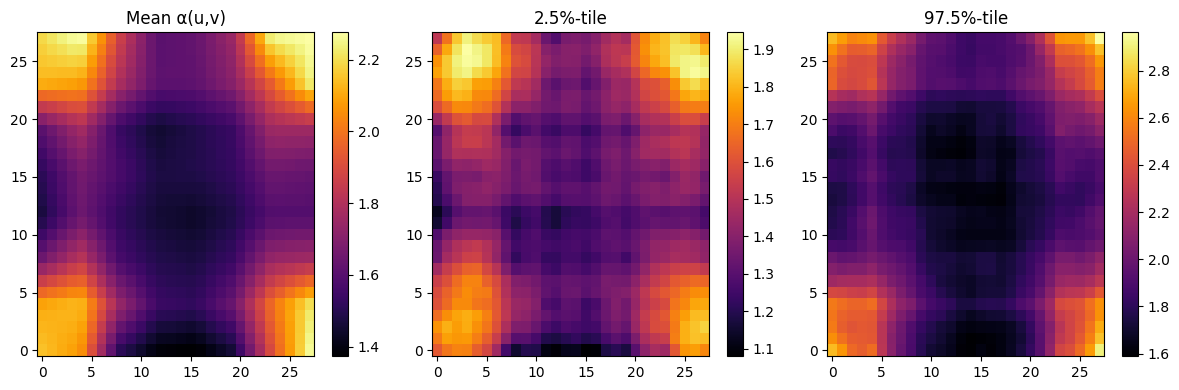

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def sample_delta_maps_2d(params, prefix, H_pad, W_pad, gh, gw, n_samples=100):
    """
    Draw n_samples of the coarse Δα‐map from the low‑rank guide posterior.
    """
    joint = f"{prefix}_joint"
    loc     = np.asarray(params[f"{joint}_loc"])
    V       = np.asarray(params[f"{joint}_V"])
    d_raw   = np.asarray(params[f"{joint}_d_raw"])
    log_tau = np.asarray(params[f"{joint}_log_tau"])
    jitter  = 1e-5

    k_half = H_pad * (W_pad//2+1)  # careful: for 2D guide dim = real+imag+G
    # but G = gh*gw comes last
    M = 2 * (H_pad*(W_pad//2+1))
    G = gh*gw
    dim = M + G

    diag = np.log1p(np.exp(d_raw)) * np.exp(log_tau) + jitter
    cov  = V.dot(V.T) + np.diag(diag)

    idx = np.arange(M, M+G)
    cov_d = cov[np.ix_(idx, idx)]
    loc_d = loc[M:M+G]

    return np.random.multivariate_normal(loc_d, cov_d, size=n_samples)

def plot_conv_alpha_envelope(params, prefix, H_pad, W_pad, gh, gw,
                             alpha_global=1.0, n_samples=200, cmap="inferno"):
    """
    Show mean & 95% envelope of the full α(u,v) heatmap.
    """
    # coarse‐map samples
    deltas = sample_delta_maps_2d(params, prefix, H_pad, W_pad, gh, gw, n_samples)
    ups = []
    for d in deltas:
        coarse = d.reshape(gh, gw)
        full = upsample_bilinear_np(coarse, H_pad, W_pad)
        ups.append(alpha_global + full)
    ups = np.stack(ups, 0)

    mean_a = ups.mean(0)
    lo_a   = np.percentile(ups,  2.5, axis=0)
    hi_a   = np.percentile(ups, 97.5, axis=0)

    fig, axes = plt.subplots(1,3, figsize=(12,4))
    for ax, arr, title in zip(axes, [mean_a, lo_a, hi_a],
                              ["Mean α(u,v)", "2.5%-tile", "97.5%-tile"]):
        im = ax.imshow(arr, origin="lower", cmap=cmap, aspect='auto')
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


# after SVI on your CIFAR‑10 conv_model:
plot_conv_alpha_envelope(
    params_conv, 
    prefix="mix", 
    H_pad=28, W_pad=28,
    gh=8, gw=8, 
    alpha_global=1.0,
    n_samples=300
)


step 0   ELBO = 8.2
step 100 ELBO = 279.0
step 200 ELBO = -97.0
step 300 ELBO = 31.1
step 400 ELBO = -93.5
final ELBO: 141.68834


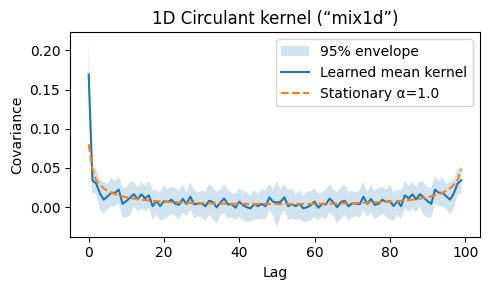

In [7]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, init_to_feasible
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoGuideList, AutoNormal

# --- 1) Corrected Chirp data generator ------------------------------------
def make_chirp_signals(N=200, D=100, noise_std=0.05):
    """
    X: (N, D) where
      - X[i, :D//2] = sin(4πt) + noise
      - X[i, D//2:] = sin(20πt) + noise
    y: the noisy midpoint X[i, D//2]
    """
    assert D % 2 == 0, "D must be even"
    half = D // 2
    t_low  = np.linspace(0, 1, half)
    t_high = np.linspace(0, 1, half)
    low_sig  = np.sin(4 * np.pi * t_low)
    high_sig = np.sin(20 * np.pi * t_high)

    X = np.zeros((N, D), float)
    y = np.zeros(N,    float)
    for i in range(N):
        noise = noise_std * np.random.randn(D)
        seq   = np.concatenate([low_sig, high_sig]) + noise
        X[i]  = seq
        # regression target: the (noisy) midpoint
        y[i]  = seq[half]
    return X, y

# build data
N, D = 200, 100
Xc, yc = make_chirp_signals(N=N, D=D)

# --- 2) reuse your circ1d_model from above -------------------------------
def circ1d_model(X, y=None):
    """
    Regression: predict the midpoint of the chirp sequence,
    forcing the spectral layer to adapt its α by frequency.
    """
    D = X.shape[1]
    circ = NonStatSpectralCirculantLayer(
        in_features=D,
        padded_dim=D,
        alpha_global=1.0,
        alpha_prior=dist.HalfNormal(1.0),
        K=None,
        name="mix1d",
        prior_fn=None,
    )
    f = circ(X)                       # shape (N, D)
    pred = f[:, D//2]                 # midpoint prediction
    sigma = 0.1                       # observation noise
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(pred, sigma), obs=y)

# --- 3) guide setup -------------------------------------------------------
from quantbayes.bnn.guide.low_rank_fft_guide import LowRankNonStat1DGuide

circ1d_guide = AutoGuideList(circ1d_model)
circ1d_guide.append(
    LowRankNonStat1DGuide(
        circ1d_model,
        prefix="mix1d",
        H_pad=D,
        W_pad=D,
        rank=8,
        jitter=1e-5,
    )
)
circ1d_guide.append(
    AutoNormal(
        numpyro.handlers.block(
            circ1d_model,
            hide=["mix1d_real","mix1d_imag","mix1d_delta_alpha"]
        ),
        init_loc_fn=init_to_feasible,
    )
)

# --- 4) run SVI ----------------------------------------------------------
def run_test(model, guide, X, y, n_steps=500, lr=1e-2):
    rng_key = jax.random.PRNGKey(0)
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    svi_state = svi.init(rng_key, X, y)
    for i in range(n_steps):
        svi_state, loss = svi.update(svi_state, X, y)
        if i % 100 == 0:
            print(f"step {i:<3d} ELBO = {loss:.1f}")
    params = svi.get_params(svi_state)
    print("final ELBO:", loss)
    return params

params_chirp = run_test(circ1d_model, circ1d_guide,
                        jnp.array(Xc), jnp.array(yc),
                        n_steps=500, lr=1e-2)

# --- 5) butterfly plot ---------------------------------------------------
# assuming plot_1d_kernel_comparison_1d is defined as before
plot_1d_kernel_comparison_1d(
    params_chirp,
    prefix="mix1d",
    W_pad=D,
    alpha_global=1.0,
    n_samples=300
)


In [122]:
class GibbsKernelLayer:
    """
    Implements a Gibbs (non‑stationary) kernel convolution:
      k(x,x') = sqrt(2 l(x) l(x') / (l(x)^2 + l(x')^2))
                * exp(-(x-x')^2 / (l(x)^2 + l(x')^2))
    where l(x) is a location–dependent lengthscale from a small net.
    Adds 1e-6 to the denominator for numerical stability.
    """
    def __init__(self, in_features, lengthscale_net, name="gibbs"):
        self.N = in_features
        self.lengthscale_net = lengthscale_net
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, N = x.shape
        assert N == self.N

        # positions 0..1
        pos = jnp.linspace(0., 1., N)
        log_l = self.lengthscale_net(pos)   # (N,)
        l     = jnp.exp(log_l)              # (N,)

        l_i   = l[:, None]                  # (N,1)
        l_j   = l[None, :]                  # (1,N)
        denom = l_i**2 + l_j**2 + 1e-6      # (N,N)

        sq  = jnp.sqrt(2 * (l_i * l_j) / denom)
        d   = (jnp.arange(N)[:,None] - jnp.arange(N)[None,:])**2
        exp = jnp.exp(-d / denom)

        K = sq * exp                       # (N,N)
        return x @ K.T                     # (B,N)


# ----------------------------------------------------------------------------
# 2) 1D Patch‑wise Spectral Mixture with PSD floor
# ----------------------------------------------------------------------------
class PatchWiseSpectralMixtureLayer:
    """
    1-D non-overlapping patchwise spectral-mixture convolution.

    The kernel hyper-parameters (w, μ, σ) are deterministic learnable
    parameters, following Wilson & Adams 2013. They are constrained by:

        w      = softmax(logits_w)         ∈ Δ^{M-1}
        μ      = 0.5 · sigmoid(raw_mu)     ∈ [0,0.5]
        σ      = 1e-3 + softplus(raw_sigma) ∈ (1e-3, ∞)

    The power spectrum is mirrored to enforce real outputs and we add the
    standard 1e-6 PSD floor for numeric robustness.
    """

    def __init__(self, in_features: int, patch_size: int,
                 n_mixtures: int = 3, name: str = "patch1d"):
        assert in_features % patch_size == 0, "in_features must be divisible by patch_size"
        self.N = in_features
        self.P = patch_size
        self.M = n_mixtures
        self.n_patches = in_features // patch_size
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, N = x.shape
        assert N == self.N, f"Expected input features {self.N}, got {N}"

        # Learnable unconstrained parameters
        logits_w = numpyro.param(f"{self.name}_logits_w",
                                  jnp.zeros((self.n_patches, self.M)))
        raw_mu = numpyro.param(f"{self.name}_raw_mu",
                                0.01 * jax.random.normal(numpyro.prng_key(),
                                                        (self.n_patches, self.M)))
        raw_sigma = numpyro.param(f"{self.name}_raw_sigma",
                                   jnp.zeros((self.n_patches, self.M)))

        w = jax.nn.softmax(logits_w, axis=-1)
        mu = 0.5 * jax.nn.sigmoid(raw_mu)
        sigma = jax.nn.softplus(raw_sigma) + 1e-3

        # Fixed frequency grid (real FFT, P even)
        freqs = jnp.fft.rfftfreq(self.P)  # shape (P/2+1,)

        patches = []
        for p in range(self.n_patches):
            xp = x[:, p * self.P: (p + 1) * self.P]  # shape (B, P)

            # Mirrored spectral density
            S = jnp.zeros_like(freqs)
            for m in range(self.M):
                S = S + w[p, m] * (
                    jnp.exp(-0.5 * ((freqs - mu[p, m]) / sigma[p, m])**2)
                    + jnp.exp(-0.5 * ((freqs + mu[p, m]) / sigma[p, m])**2)
                )
            S = S + 1e-6  # PSD floor

            Xf = jnp.fft.rfft(xp, axis=-1)  # shape (B, P/2+1)
            yp = jnp.fft.irfft(Xf * S[None, :], n=self.P, axis=-1)
            patches.append(yp)

        return jnp.concatenate(patches, axis=-1)  # shape (B, N)


class InputWarpingLayer:
    def __init__(self, in_features, warp_net, base_psd, name="warp"):
        self.N = in_features
        self.warp_net = warp_net      # function pos→offset
        self.base_psd = base_psd      # function freqs→S(freq)
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x : (batch,N)
        batch, N = x.shape
        assert N == self.N

        # positions in [0,1]
        pos = jnp.linspace(0., 1., N)
        # learn offsets Δu(pos)
        delta_u = self.warp_net(pos)            # (N,)
        u       = pos + delta_u                 # (N,)

        # reinterpolate each sequence onto uniform grid
        def interp_one(seq):
            # jnp.interp is supported in JAX
            return jnp.interp(pos, u, seq)

        x_warp = jax.vmap(interp_one)(x)         # (batch,N)

        # stationary conv in warped space
        freqs = jnp.fft.fftfreq(N)               # (N,)
        S     = self.base_psd(freqs)             # (N,)
        Xf    = jnp.fft.fft(x_warp, axis=-1)     # (batch,N)
        y     = jnp.fft.ifft(Xf * S[None,:], axis=-1).real  # (batch,N)
        return y



In [135]:
import jax
import jax.numpy as jnp
import numpyro

# -------------------------
# 2D Gibbs Kernel Layer (separable)
# -------------------------
class GibbsKernel2DLayer:
    """
    Separable 2D Gibbs kernel: k((i,j),(i',j')) = k_x(i,i') * k_y(j,j')
    where k_x, k_y are 1D Gibbs kernels from lengthscale nets.
    """
    def __init__(self, H, W, lengthscale_net_x, lengthscale_net_y, name="gibbs2d"):
        self.H, self.W = H, W
        self.net_x = lengthscale_net_x  # maps pos_x -> log l_x
        self.net_y = lengthscale_net_y  # maps pos_y -> log l_y
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x: (batch, H, W)
        B, H, W = x.shape
        assert (H, W) == (self.H, self.W)
        # positions
        pos_x = jnp.linspace(0., 1., W)
        pos_y = jnp.linspace(0., 1., H)
        # lengthscales
        lx = jnp.exp(self.net_x(pos_x))  # (W,)
        ly = jnp.exp(self.net_y(pos_y))  # (H,)
        # 1D Gibbs kernels
        def gibbs1d(pos, ell):
            d = pos[:, None] - pos[None, :]
            l_i = ell[:, None]; l_j = ell[None, :]
            denom = l_i**2 + l_j**2
            sq = jnp.sqrt(2 * l_i * l_j / denom)
            return sq * jnp.exp(-d**2 / denom)
        Kx = gibbs1d(pos_x, lx)  # (W,W)
        Ky = gibbs1d(pos_y, ly)  # (H,H)
        # separable convolution: first along width (x-axis), then height (y-axis)
        # apply per-row 1D conv along width
        x1 = jnp.einsum('bhw,wd->bhd', x, Kx)  # (B,H,W)
        # apply per-column conv along height
        y = jnp.einsum('bhd,hk->bkd', x1, Ky)  # (B,H,W)
        return y  # shape (B,H,W)

# -----------------------------------------------------------------------------
# 2D patch‑wise spectral mixture layer
# -----------------------------------------------------------------------------
class PatchWiseSpectralMixture2DLayer:
    """
    2-D non-overlapping patchwise spectral-mixture convolution.

    The PSD is a sum of axis-separable bivariate Gaussians, mirrored in both
    frequency axes. Hyper-parameters are deterministic and constrained as in
    the 1-D case.
    """

    def __init__(self, H: int, W: int, patch_h: int, patch_w: int,
                 n_mixtures: int = 3, name: str = "patch2d"):
        assert H % patch_h == 0 and W % patch_w == 0, \
            "Height and width must be divisible by patch size"
        self.H, self.W = H, W
        self.ph, self.pw = patch_h, patch_w
        self.nh, self.nw = H // patch_h, W // patch_w
        self.M = n_mixtures
        self.name = name
        self.npatch = self.nh * self.nw

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, H, W = x.shape
        assert (H, W) == (self.H, self.W), \
            f"Expected input shape ({self.H}, {self.W}), got ({H}, {W})"

        # get unconstrained params
        logits_w = numpyro.param(f"{self.name}_logits_w",
                                  jnp.zeros((self.npatch, self.M)))
        raw_mu = numpyro.param(f"{self.name}_raw_mu",
                                0.01 * jax.random.normal(
                                    numpyro.prng_key(),
                                    (self.npatch, self.M, 2)
                                ))
        raw_sigma = numpyro.param(f"{self.name}_raw_sigma",
                                   jnp.zeros((self.npatch, self.M, 2)))

        w = jax.nn.softmax(logits_w, axis=-1)
        mu = 0.5 * jax.nn.sigmoid(raw_mu)
        sigma = jax.nn.softplus(raw_sigma) + 1e-3

        # full frequency grid
        fy = jnp.fft.fftfreq(self.ph)          # (ph,)
        fx = jnp.fft.fftfreq(self.pw)          # (pw,)
        FY, FX = jnp.meshgrid(fy, fx, indexing='ij')  # (ph,pw)

        out_rows = []
        idx = 0
        for i in range(self.nh):
            row_patches = []
            for j in range(self.nw):
                sub = x[:, i*self.ph:(i+1)*self.ph,
                         j*self.pw:(j+1)*self.pw]  # (B, ph, pw)

                # build PSD S over full grid
                S = jnp.zeros_like(FY)
                for m in range(self.M):
                    dy = (FY - mu[idx, m, 0]) / sigma[idx, m, 0]
                    dx = (FX - mu[idx, m, 1]) / sigma[idx, m, 1]
                    gauss = jnp.exp(-0.5 * (dy**2 + dx**2))
                    dy_m = (FY + mu[idx, m, 0]) / sigma[idx, m, 0]
                    dx_m = (FX + mu[idx, m, 1]) / sigma[idx, m, 1]
                    gauss_m = jnp.exp(-0.5 * (dy_m**2 + dx_m**2))
                    S = S + w[idx, m] * (gauss + gauss_m)
                S = S + 1e-6  # PSD floor

                # full FFT conv
                Xf = jnp.fft.fftn(sub, axes=(1,2))
                y_patch = jnp.fft.ifftn(Xf * S[None, :, :],
                                       axes=(1,2)).real

                row_patches.append(y_patch)
                idx += 1
            out_rows.append(jnp.concatenate(row_patches, axis=2))

        return jnp.concatenate(out_rows, axis=1)  # (B,H,W)


# -------------------------
# 2D Input Warping Layer
# -------------------------
class InputWarping2DLayer:
    """
    Separable 2D warp: warp rows then warp columns with learned monotonic mapping.
    """
    def __init__(self, H, W, warp_net_x, warp_net_y, base_psd, name="warp2d"):
        self.H, self.W = H, W
        self.warp_x, self.warp_y = warp_net_x, warp_net_y
        self.base_psd = base_psd
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x: (batch,H,W)
        B,H,W = x.shape
        pos_x = jnp.linspace(0.,1.,W)
        pos_y = jnp.linspace(0.,1.,H)
        # 1D warps
        def make_u(net, pos):
            raw = net(pos)
            inc = jax.nn.softplus(raw)
            cs = jnp.cumsum(inc)
            return (cs - cs[0])/(cs[-1]-cs[0])
        ux = make_u(self.warp_x, pos_x)  # (W,)
        uy = make_u(self.warp_y, pos_y)  # (H,)
        # warp X: rows -> warp_x
        def warp_rows(img):
            return jnp.stack([jnp.interp(pos_x, ux, row) for row in img], axis=0)
        x1 = jax.vmap(warp_rows)(x)
        # warp Y: columns -> warp_y
        def warp_cols(img):
            return jnp.stack([jnp.interp(pos_y, uy, col) for col in img.T], axis=1)
        x2 = jax.vmap(warp_cols)(x1)
        # circulant 2D FFT conv
        fy = jnp.fft.fftfreq(H)
        fx = jnp.fft.fftfreq(W)
        FY, FX = jnp.meshgrid(fy, fx, indexing='ij')
        S = self.base_psd(FY, FX)  # (H,W)
        Sf = S[None,:,:]
        Xf = jnp.fft.fftn(x2, axes=(1,2))
        y = jnp.fft.ifftn(Xf * Sf, axes=(1,2)).real
        return y



gibbs 1d test...
Step 0100 ELBO: 114.256
Step 0200 ELBO: 119.354
Step 0300 ELBO: 94.883
Step 0400 ELBO: 87.764
Step 0500 ELBO: 94.209


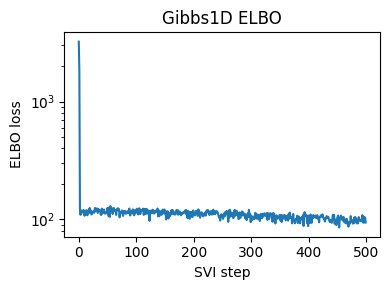

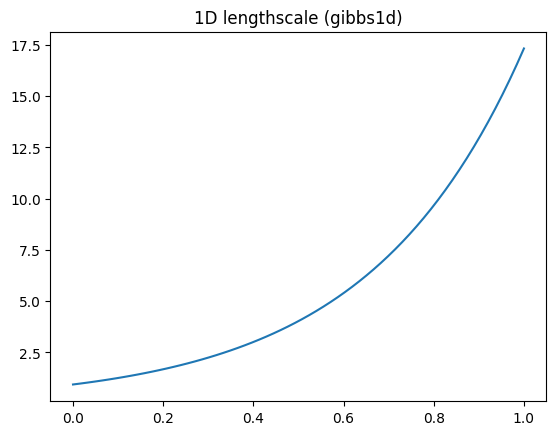

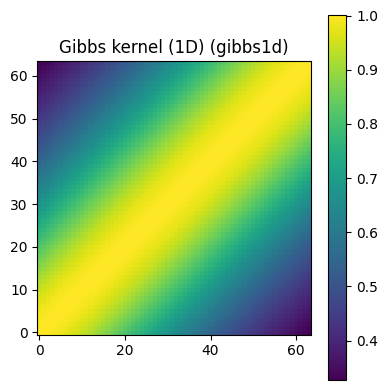

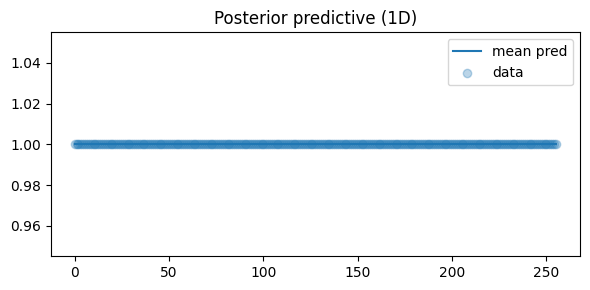

patch mixture 1d test...
Step 0100 ELBO: 90.370
Step 0200 ELBO: 66.501
Step 0300 ELBO: 25.121
Step 0400 ELBO: 17.228
Step 0500 ELBO: 14.787


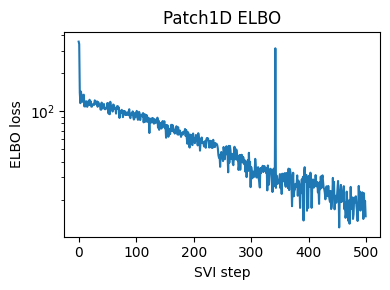

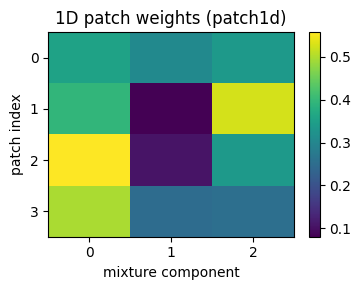

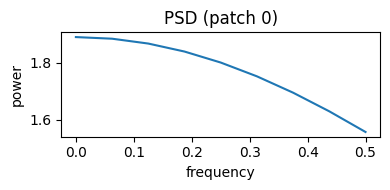

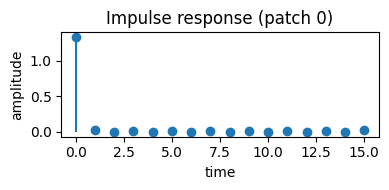

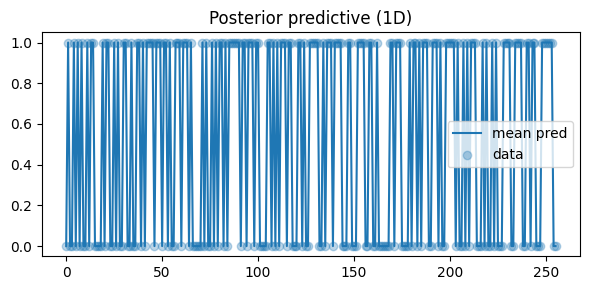

warp 1d test...
Step 0100 ELBO: 83.097
Step 0200 ELBO: 53.739
Step 0300 ELBO: 16.358
Step 0400 ELBO: 9.949
Step 0500 ELBO: 8.537


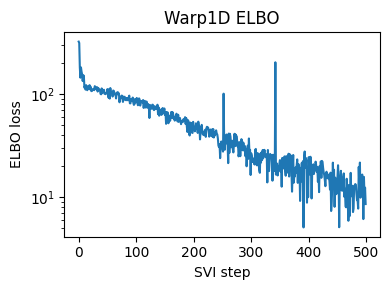

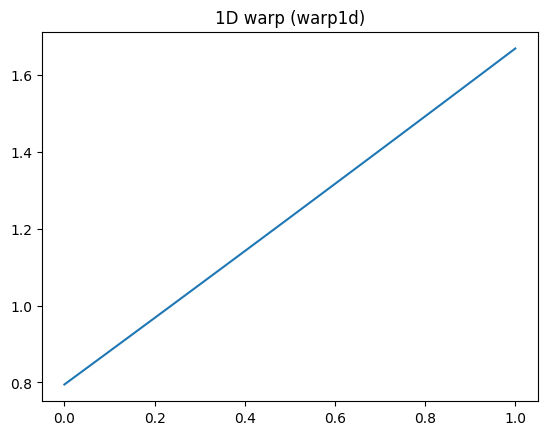

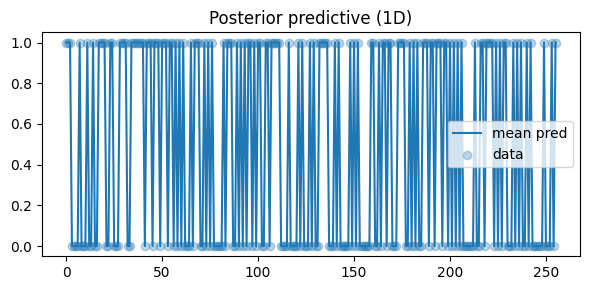

gibbs 2d test...
Step 0100 ELBO: 2838.604
Step 0200 ELBO: 2843.908
Step 0300 ELBO: 2781.853
Step 0400 ELBO: 2731.345
Step 0500 ELBO: 2683.668


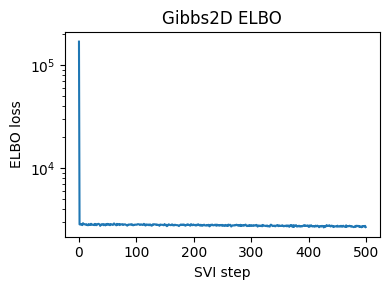

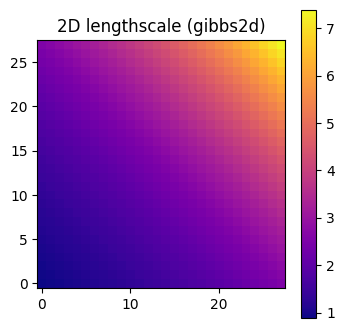

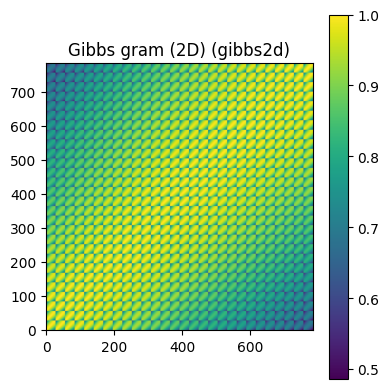

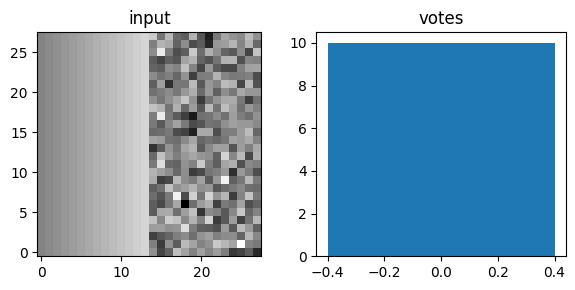

patch mixture 2d test...
Step 0100 ELBO: 2087.086
Step 0200 ELBO: 848.363
Step 0300 ELBO: 220.809
Step 0400 ELBO: 38.559
Step 0500 ELBO: 17.861


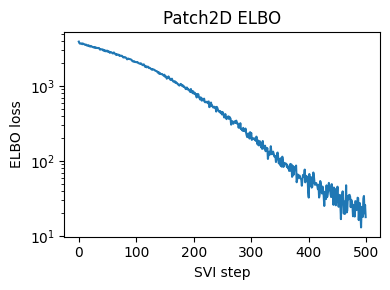

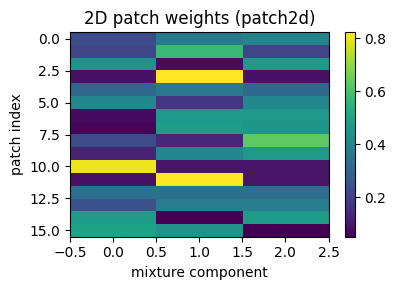

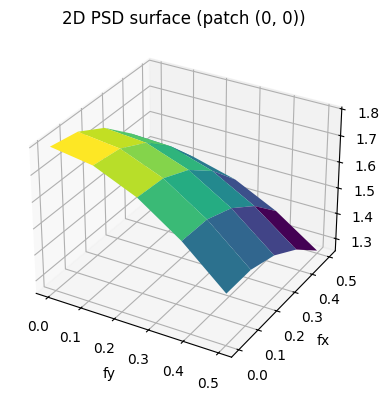

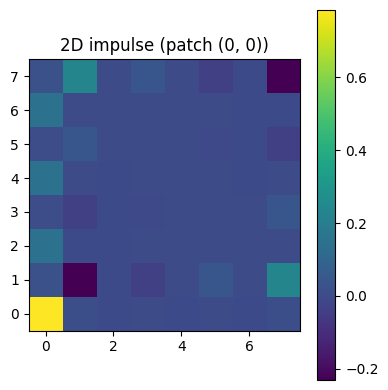

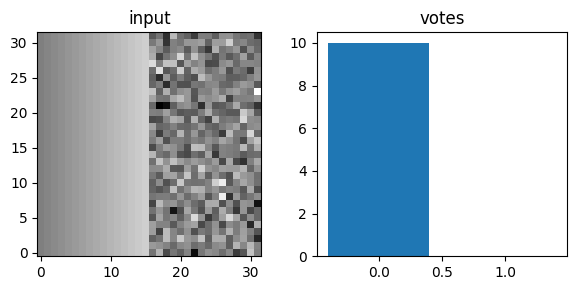

warping 2d test...
Step 0100 ELBO: 1632.296
Step 0200 ELBO: 684.313
Step 0300 ELBO: 189.727
Step 0400 ELBO: 69.450
Step 0500 ELBO: 25.218


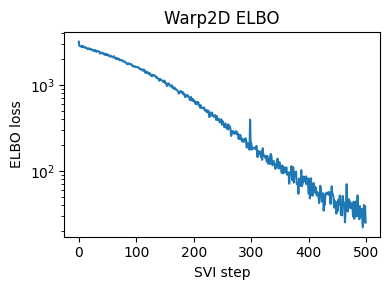

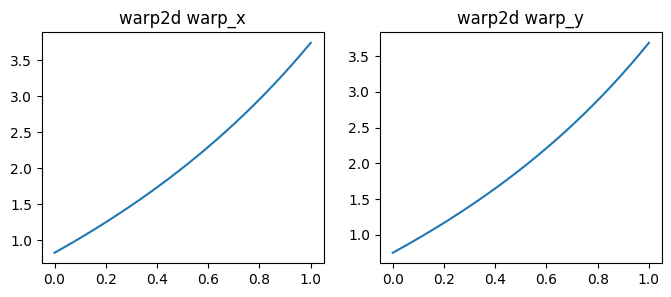

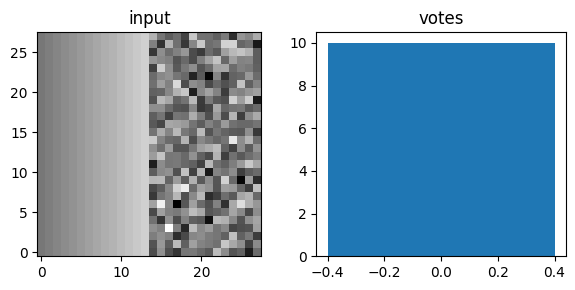

All done!


In [ ]:
# exp.py

import jax
import jax.numpy as jnp
import numpy as np
import numpy as onp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, init_to_feasible
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal


# ------------------------------------------------------------------
# Helpers: synthetic data + runner + basic plots
# ------------------------------------------------------------------
def make_jump_1d(N=256, D=64, noise=0.1):
    assert D % 2 == 0
    half = D // 2
    X = np.zeros((N, D))
    y = np.zeros(N, int)
    for i in range(N):
        left  = 1.0 + noise * np.random.randn(half)
        right = 2.0 + noise * np.random.randn(half)
        X[i] = np.concatenate([left, right])
        y[i] = int(right.mean() > left.mean())
    return jnp.array(X), jnp.array(y)

def make_ramp_1d(N=256, D=64, noise=0.05):
    t = np.linspace(0, 1, D)
    X = np.zeros((N, D))
    y = np.zeros(N, int)
    for i in range(N):
        s = np.random.choice([-1, 1])
        seq = s*t + noise*np.random.randn(D)
        X[i] = seq
        y[i] = int(s > 0)
    return jnp.array(X), jnp.array(y)

def make_half_smooth_noisy(N=256, H=28, W=28, noise=0.5):
    X = np.zeros((N, H, W))
    y = np.zeros(N, int)
    smooth = np.linspace(0, 1, W//2)[None, :]
    for i in range(N):
        left  = np.tile(smooth, (H,1))
        right = noise * np.random.randn(H, W//2)
        img = np.concatenate([left, right], axis=1)
        X[i] = img
        y[i] = int(img.mean() > 0.5)
    return jnp.array(X), jnp.array(y)

def run_svi(model, guide, X, y, lr=1e-2, n_steps=500):
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    state = svi.init(jax.random.PRNGKey(0), X, y)
    losses = []
    for i in range(1, n_steps+1):
        state, loss = svi.update(state, X, y)
        losses.append(loss)
        if i % 100 == 0:
            print(f"Step {i:04d} ELBO: {loss:.3f}")
    params = svi.get_params(state)
    return params, np.array(losses)

def plot_losses(losses, title):
    plt.figure(figsize=(4,3))
    plt.plot(losses)
    plt.yscale("log")
    plt.title(title)
    plt.xlabel("SVI step")
    plt.ylabel("ELBO loss")
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# Plotting helpers that pull raw params out of the SVI `params` dict
# -----------------------------------------------------------------------------

def get_patch1d_params(params, prefix, patch_idx):
    logits_w  = params[f"{prefix}_logits_w"][patch_idx]   # (M,)
    raw_mu    = params[f"{prefix}_raw_mu"][patch_idx]     # (M,)
    raw_sigma = params[f"{prefix}_raw_sigma"][patch_idx]  # (M,)
    w     = jax.nn.softmax(logits_w)
    mu    = 0.5 * jax.nn.sigmoid(raw_mu)
    sigma = jax.nn.softplus(raw_sigma) + 1e-3
    return onp.asarray(w), onp.asarray(mu), onp.asarray(sigma)

def plot_patch_weights_1d(params, prefix, nchunks, M):
    logits = onp.asarray(params[f"{prefix}_logits_w"])    # (nchunks, M)
    W = jax.nn.softmax(logits, axis=-1)
    plt.figure(figsize=(4,3))
    plt.imshow(W, aspect="auto", cmap="viridis")
    plt.colorbar()
    plt.title(f"1D patch weights ({prefix})")
    plt.xlabel("mixture component")
    plt.ylabel("patch index")
    plt.tight_layout()
    plt.show()

def plot_patch_psd_1d(params, prefix, patch=0, P=16):
    freqs = onp.asarray(jnp.fft.rfftfreq(P))
    w, mu, sigma = get_patch1d_params(params, prefix, patch)
    S = onp.zeros_like(freqs)
    for m in range(len(w)):
        S += w[m] * (
            onp.exp(-0.5*((freqs-mu[m])/sigma[m])**2) +
            onp.exp(-0.5*((freqs+mu[m])/sigma[m])**2)
        )
    plt.figure(figsize=(4,2))
    plt.plot(freqs, S)
    plt.title(f"PSD (patch {patch})")
    plt.xlabel("frequency")
    plt.ylabel("power")
    plt.tight_layout()
    plt.show()

def plot_patch_irf_1d(params, prefix, patch=0, P=16):
    freqs = onp.asarray(jnp.fft.rfftfreq(P))
    w, mu, sigma = get_patch1d_params(params, prefix, patch)
    S = onp.zeros_like(freqs)
    for m in range(len(w)):
        S += w[m] * (
            onp.exp(-0.5*((freqs-mu[m])/sigma[m])**2) +
            onp.exp(-0.5*((freqs+mu[m])/sigma[m])**2)
        )
    h = onp.fft.irfft(onp.sqrt(S)[None,:], n=P, axis=-1)[0]
    plt.figure(figsize=(4,2))
    plt.stem(onp.arange(P), h, basefmt=" ")
    plt.title(f"Impulse response (patch {patch})")
    plt.xlabel("time")
    plt.ylabel("amplitude")
    plt.tight_layout()
    plt.show()

def get_patch2d_params(params, prefix, patch_idx):
    logits_w  = params[f"{prefix}_logits_w"][patch_idx]    # (M,)
    raw_mu    = params[f"{prefix}_raw_mu"][patch_idx]      # (M,2)
    raw_sigma = params[f"{prefix}_raw_sigma"][patch_idx]   # (M,2)
    w     = jax.nn.softmax(logits_w)
    mu    = 0.5 * jax.nn.sigmoid(raw_mu)
    sigma = jax.nn.softplus(raw_sigma) + 1e-3
    return onp.asarray(w), onp.asarray(mu), onp.asarray(sigma)

def plot_patch_weights_2d(params, prefix, nchunks, M):
    # Flattened: nchunks = total number of patches = nh*nw
    logits = onp.asarray(params[f"{prefix}_logits_w"])  # (nchunks, M)
    W = jax.nn.softmax(logits, axis=-1)
    plt.figure(figsize=(4,3))
    plt.imshow(W, aspect="auto", cmap="viridis")
    plt.colorbar()
    plt.title(f"2D patch weights ({prefix})")
    plt.xlabel("mixture component")
    plt.ylabel("patch index")
    plt.tight_layout()
    plt.show()

def plot_patch_psd_2d(params, prefix, patch=(0,0), ph=8, pw=8):
    nh = params[f"{prefix}_logits_w"].shape[0]
    nw = nh  # if you know it's square; otherwise pass both dims
    idx = patch[0]*nw + patch[1]
    w, mu, sigma = get_patch2d_params(params, prefix, idx)
    fy = onp.asarray(jnp.fft.rfftfreq(ph))
    fx = onp.asarray(jnp.fft.rfftfreq(pw))
    FY, FX = onp.meshgrid(fy, fx, indexing="ij")
    S = onp.zeros_like(FY)
    for m in range(len(w)):
        dy = (FY - mu[m,0]) / sigma[m,0]
        dx = (FX - mu[m,1]) / sigma[m,1]
        S += w[m] * (
            onp.exp(-0.5*(dy**2+dx**2)) +
            onp.exp(-0.5*(((FY+mu[m,0])/sigma[m,0])**2 + ((FX+mu[m,1])/sigma[m,1])**2))
        )
    from mpl_toolkits.mplot3d import Axes3D  # noqa
    fig = plt.figure(figsize=(4,4))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(FY, FX, S, cmap="viridis")
    ax.set_title(f"2D PSD surface (patch {patch})")
    ax.set_xlabel("fy"); ax.set_ylabel("fx"); ax.set_zlabel("power")
    plt.tight_layout()
    plt.show()

def plot_patch_irf_2d(params, prefix, patch=(0,0), ph=8, pw=8):
    nh = params[f"{prefix}_logits_w"].shape[0]
    nw = nh
    idx = patch[0]*nw + patch[1]
    w, mu, sigma = get_patch2d_params(params, prefix, idx)
    fy = onp.asarray(jnp.fft.rfftfreq(ph))
    fx = onp.asarray(jnp.fft.rfftfreq(pw))
    FY, FX = onp.meshgrid(fy, fx, indexing="ij")
    S = onp.zeros_like(FY)
    for m in range(len(w)):
        dy = (FY - mu[m,0]) / sigma[m,0]
        dx = (FX - mu[m,1]) / sigma[m,1]
        S += w[m] * (
            onp.exp(-0.5*(dy**2+dx**2)) +
            onp.exp(-0.5*(((FY+mu[m,0])/sigma[m,0])**2 + ((FX+mu[m,1])/sigma[m,1])**2))
        )
    h2d = onp.fft.irfftn(onp.sqrt(S)[None,:,:], s=(ph,pw), axes=(1,2))[0]
    plt.figure(figsize=(4,4))
    plt.imshow(h2d, origin="lower")
    plt.colorbar()
    plt.title(f"2D impulse (patch {patch})")
    plt.tight_layout()
    plt.show()

def plot_gibbs_kernel_1d(params, prefix, D=64):
    b, w = onp.asarray(params[f"{prefix}_lengthscale_net_param"])
    pos = onp.linspace(0,1,D)
    l   = onp.exp(b + w*pos)
    Li, Lj = l[:,None], l[None,:]
    denom = Li**2 + Lj**2
    K = onp.sqrt(2*Li*Lj/denom) * onp.exp(-(pos[:,None]-pos[None,:])**2/denom)
    plt.figure(figsize=(4,4))
    plt.imshow(K, origin="lower")
    plt.colorbar()
    plt.title(f"Gibbs kernel (1D) ({prefix})")
    plt.tight_layout()
    plt.show()

def plot_gibbs_kernel_2d(params, prefix, H=28, W=28):
    bx, wx = onp.asarray(params[f"{prefix}_net_x"])
    by, wy = onp.asarray(params[f"{prefix}_net_y"])
    px = onp.linspace(0,1,W)
    py = onp.linspace(0,1,H)
    lx = onp.exp(bx + wx*px)
    ly = onp.exp(by + wy*py)
    Xi, Xj = onp.meshgrid(px, px, indexing="ij")
    Li, Lj = lx[:,None], lx[None,:]
    denom_x = Li**2 + Lj**2
    Kx = onp.sqrt(2*Li*Lj/denom_x) * onp.exp(-(Xi-Xj)**2/denom_x)
    Yi, Yj = onp.meshgrid(py, py, indexing="ij")
    Li, Lj = ly[:,None], ly[None,:]
    denom_y = Li**2 + Lj**2
    Ky = onp.sqrt(2*Li*Lj/denom_y) * onp.exp(-(Yi-Yj)**2/denom_y)
    K2d = onp.kron(Ky, Kx)
    plt.figure(figsize=(4,4))
    plt.imshow(K2d, origin="lower")
    plt.colorbar()
    plt.title(f"Gibbs gram (2D) ({prefix})")
    plt.tight_layout()
    plt.show()

def plot_predictive_1d(model, guide, params, X, y, n_samples=20):
    predictive = Predictive(
        model, guide=guide, params=params,
        num_samples=n_samples, return_sites=["obs"]
    )
    samples = predictive(jax.random.PRNGKey(1), X, None)["obs"]
    mean_pred = onp.mean(samples, axis=0)
    plt.figure(figsize=(6,3))
    plt.plot(mean_pred, label="mean pred")
    plt.scatter(onp.arange(len(y)), onp.asarray(y),
                alpha=0.3, label="data")
    plt.legend()
    plt.title("Posterior predictive (1D)")
    plt.tight_layout()
    plt.show()

def plot_predictive_2d(model, guide, params, X, y, idx=0, n_samples=10):
    predictive = Predictive(
        model, guide=guide, params=params,
        num_samples=n_samples, return_sites=["obs"]
    )
    samples = predictive(jax.random.PRNGKey(2), X, None)["obs"]
    inp = onp.asarray(X[idx])
    vote = onp.bincount(onp.asarray(samples[:,idx]),
                        minlength=int(samples.max())+1)
    fig, ax = plt.subplots(1,2,figsize=(6,3))
    ax[0].imshow(inp, cmap="gray", origin="lower")
    ax[0].set_title("input")
    ax[1].bar(range(len(vote)), vote)
    ax[1].set_title("votes")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# Your six NumPyro models
# ------------------------------------------------------------------
def gibbs1d_model(X, y=None):
    def net(pos):
        b, w = numpyro.param("gibbs1d_lengthscale_net_param",
                              jnp.array([0.0, 3.0]))
        return b + w*pos
    out = GibbsKernelLayer(64, net, name="gibbs1d")(X)
    W = numpyro.sample("W",
        dist.Normal(0,1).expand([64,1]).to_event(2))
    b = numpyro.sample("b",
        dist.Normal(0,1).expand([1]).to_event(1))
    logits = jnp.squeeze(out @ W + b)
    numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

def patch1d_model(X, y=None):
    out = PatchWiseSpectralMixtureLayer(
        in_features=64, patch_size=16, n_mixtures=3, name="patch1d"
    )(X)
    W = numpyro.sample("W",
        dist.Normal(0,1).expand([64,1]).to_event(2))
    b = numpyro.sample("b",
        dist.Normal(0,1).expand([1]).to_event(1))
    logits = jnp.squeeze(out @ W + b)
    numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

def warp1d_model(X, y=None):
    def net(pos):
        b, w = numpyro.param("warp1d_net_param", jnp.zeros((2,)))
        return b + w*pos
    out = InputWarpingLayer(64, net,
                            base_psd=lambda f: jnp.ones_like(f),
                            name="warp1d")(X)
    W = numpyro.sample("W",
        dist.Normal(0,1).expand([64,1]).to_event(2))
    b = numpyro.sample("b",
        dist.Normal(0,1).expand([1]).to_event(1))
    logits = jnp.squeeze(out @ W + b)
    numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

def gibbs2d_model(X, y=None):
    def netx(pos):
        b, w = numpyro.param("gibbs2d_net_x", jnp.array([0.0,1.0]))
        return b + w*pos
    def nety(pos):
        b, w = numpyro.param("gibbs2d_net_y", jnp.array([0.0,1.0]))
        return b + w*pos
    out = GibbsKernel2DLayer(28,28, netx, nety, name="gibbs2d")(X)
    h = out.reshape(out.shape[0], -1)
    W = numpyro.sample("W",
        dist.Normal(0,1).expand([h.shape[-1],2]).to_event(2))
    b = numpyro.sample("b",
        dist.Normal(0,1).expand([2]).to_event(1))
    logits = h @ W + b
    numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

def patch2d_model(X, y=None):
    out = PatchWiseSpectralMixture2DLayer(
        H=32, W=32, patch_h=8, patch_w=8, n_mixtures=3, name="patch2d"
    )(X)
    h = out.reshape(out.shape[0], -1)
    W = numpyro.sample("W",
        dist.Normal(0,1).expand([h.shape[-1],2]).to_event(2))
    b = numpyro.sample("b",
        dist.Normal(0,1).expand([2]).to_event(1))
    logits = h @ W + b
    numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

def warp2d_model(X, y=None):
    abx = numpyro.param("warp2d_x", jnp.array([0.,1.]))
    aby = numpyro.param("warp2d_y", jnp.array([0.,1.]))
    warp_x = lambda pos: abx[0] + abx[1]*pos
    warp_y = lambda pos: aby[0] + aby[1]*pos
    out = InputWarping2DLayer(
        H=28, W=28,
        warp_net_x=warp_x, warp_net_y=warp_y,
        base_psd=lambda fy,fx: jnp.ones_like(fy),
        name="warp2d"
    )(X)
    h = out.reshape(out.shape[0], -1)
    W = numpyro.sample("W",
        dist.Normal(0,1).expand([h.shape[-1],2]).to_event(2))
    b = numpyro.sample("b",
        dist.Normal(0,1).expand([2]).to_event(1))
    logits = h @ W + b
    numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

# ------------------------------------------------------------------------------
# Main: run each of the six models and plot
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    # 1) 1D Gibbs
    print("gibbs 1d test...")
    X1, y1 = make_jump_1d(256, 64)
    guide1 = AutoNormal(gibbs1d_model, init_loc_fn=init_to_feasible)
    p1, l1 = run_svi(gibbs1d_model, guide1, X1, y1)
    plot_losses(l1, "Gibbs1D ELBO")
    plot_gibbs_kernel_1d(p1, "gibbs1d", 64)
    plot_predictive_1d(gibbs1d_model, guide1, p1, X1, y1)

    # 2) 1D Patch‑Mixture
    print("patch mixture 1d test...")
    X2, y2 = make_ramp_1d(256, 64)
    guide2 = AutoNormal(patch1d_model, init_loc_fn=init_to_feasible)
    p2, l2 = run_svi(patch1d_model, guide2, X2, y2)
    plot_losses(l2, "Patch1D ELBO")
    plot_patch_weights_1d(p2, "patch1d", 64//16, 3)
    plot_patch_psd_1d(p2, "patch1d", patch=0, P=16)
    plot_patch_irf_1d(p2, "patch1d", patch=0, P=16)
    plot_predictive_1d(patch1d_model, guide2, p2, X2, y2)

    # 3) 1D Warping
    print("warp 1d test...")
    X3, y3 = make_ramp_1d(256, 64)
    guide3 = AutoNormal(warp1d_model, init_loc_fn=init_to_feasible)
    p3, l3 = run_svi(warp1d_model, guide3, X3, y3)
    plot_losses(l3, "Warp1D ELBO")
    plot_predictive_1d(warp1d_model, guide3, p3, X3, y3)

    # 4) 2D Gibbs
    print("gibbs 2d test...")
    X4, y4 = make_half_smooth_noisy(256, 28, 28)
    guide4 = AutoNormal(gibbs2d_model, init_loc_fn=init_to_feasible)
    p4, l4 = run_svi(gibbs2d_model, guide4, X4, y4)
    plot_losses(l4, "Gibbs2D ELBO")
    plot_gibbs_kernel_2d(p4, "gibbs2d", 28, 28)
    plot_predictive_2d(gibbs2d_model, guide4, p4, X4, y4, idx=0)

    # 5) 2D Patch‑Mixture
    print("patch mixture 2d test...")
    X5, y5 = make_half_smooth_noisy(256, 32, 32)
    guide5 = AutoNormal(patch2d_model, init_loc_fn=init_to_feasible)
    p5, l5 = run_svi(patch2d_model, guide5, X5, y5)
    plot_losses(l5, "Patch2D ELBO")
    # **flattened nchunks = nh*nw = (32//8)*(32//8) = 16**
    plot_patch_weights_2d(p5, "patch2d", (32//8)*(32//8), 3)
    plot_patch_psd_2d      (p5, "patch2d", patch=(0,0), ph=8, pw=8)
    plot_patch_irf_2d      (p5, "patch2d", patch=(0,0), ph=8, pw=8)
    plot_predictive_2d     (patch2d_model, guide5, p5, X5, y5, idx=0)

    # 6) 2D Warping
    print("warping 2d test...")
    X6, y6 = make_half_smooth_noisy(256, 28, 28)
    guide6 = AutoNormal(warp2d_model, init_loc_fn=init_to_feasible)
    p6, l6 = run_svi(warp2d_model, guide6, X6, y6)
    plot_losses(l6, "Warp2D ELBO")
    plot_predictive_2d(warp2d_model, guide6, p6, X6, y6, idx=0)

    print("All done!")  


## Energy conserving subsampling HMC

In [73]:
"""
mcmc_utils.py

A lightweight utility module for running NUTS and HMCECS (energy-conserving subsampling HMC)
with minimal boilerplate. Simply import `sample_hmcecs` and pass your model,
training data, and desired parameters.
"""
import time
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, HMC, HMCECS, SVI, Trace_ELBO, autoguide


def fit_reference(rng_key, model, guide, optimizer, num_svi_steps,
                  X, y, subsample_size):
    """
    Fit a reference point via SVI (AutoDelta) for use with HMCECS.
    Returns a dict of reference parameter values.
    """
    svi = SVI(model, guide, optimizer, Trace_ELBO())
    result = svi.run(rng_key, num_svi_steps, X, y, subsample_size,
                     progress_bar=False)
    # extract *_auto_loc entries and strip suffix
    ref_params = {name.replace("_auto_loc", ""): result.params[name]
                  for name in result.params}
    return ref_params


def build_kernel_hmcecs(model_fn, ref_params, num_blocks=10):
    """Build an HMCECS kernel given reference parameters."""
    proxy = HMCECS.taylor_proxy(ref_params)
    # use NUTS as the inner integrator
    return HMCECS(NUTS(model_fn), num_blocks=num_blocks, proxy=proxy)


def run_mcmc(rng_key, model_fn, X, y, kernel,
             num_warmup, num_samples, subsample_size, progress_bar):
    """
    Generic MCMC runner. Returns the MCMC object after sampling.
    """
    mcmc = MCMC(kernel,
                num_warmup=num_warmup,
                num_samples=num_samples,
                progress_bar=progress_bar)
    mcmc.run(rng_key, X, y, subsample_size)
    return mcmc


def sample_hmcecs(rng_key, model_fn, X, y,
                  subsample_size,
                  num_svi_steps=1000,
                  num_warmup=500,
                  num_samples=1000,
                  num_blocks=10,
                  progress_bar=False):
    """
    Run HMCECS: performs one SVI fit for reference, then energy-conserving HMC
    with data subsampling. Returns a dict of posterior samples.
    """
    # 1) Fit reference via SVI
    guide = autoguide.AutoDelta(model_fn)
    optimizer = numpyro.optim.Adam(1e-3)
    ref_params = fit_reference(rng_key,
                               model_fn, guide, optimizer,
                               num_svi_steps,
                               X, y, subsample_size)
    # 2) Build HMCECS kernel
    kernel = build_kernel_hmcecs(model_fn, ref_params, num_blocks)
    # 3) Run MCMC with subsampling
    mcmc = run_mcmc(rng_key, model_fn, X, y,
                    kernel, num_warmup, num_samples,
                    subsample_size=subsample_size,
                    progress_bar=progress_bar)
    return mcmc.get_samples()


# Example usage for ECSS HMC
if __name__ == "__main__":
    import numpy as np
    from jax import random

    # Define your model; must accept (X, y, subsample_size)
    def logistic_model(X, y=None, subsample_size=None):
        D = X.shape[1]
        W = numpyro.sample("W", dist.Normal(0, 1).expand([D]).to_event(1))
        b = numpyro.sample("b", dist.Normal(0, 1))
        if subsample_size:
            with numpyro.plate("data", X.shape[0], subsample_size=subsample_size):
                batch_X = numpyro.subsample(X, event_dim=1)
                batch_y = numpyro.subsample(y, event_dim=0) if y is not None else None
                logits = jnp.dot(batch_X, W) + b
                numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=batch_y)
        else:
            logits = jnp.dot(X, W) + b
            with numpyro.plate("data", X.shape[0]):
                numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    # Load or generate your training data
    N, D = 5000, 10
    X_train = np.random.randn(N, D)
    y_train = (X_train @ np.ones(D) + np.random.randn(N) > 0).astype(int)

    rng_key = random.PRNGKey(42)

    # Run energy-conserving subsampling HMC (HMCECS)
    samples = sample_hmcecs(rng_key, logistic_model,
                            X_train, y_train,
                            subsample_size=500,
                            num_svi_steps=2000,
                            num_warmup=1000,
                            num_samples=2000,
                            num_blocks=20,
                            progress_bar=True)

    print("ECSS HMC completed; obtained", len(samples[list(samples.keys())[0]]), "samples.")


sample: 100%|██████████| 3000/3000 [00:03<00:00, 841.02it/s, 7 steps of size 4.82e-01. acc. prob=0.88]  

ECSS HMC completed; obtained 2000 samples.


 500  ELBO = -4304.022
1000  ELBO = -1637.535
1500  ELBO = -1048.834
2000  ELBO = -881.347
2500  ELBO = -456.641
3000  ELBO = -402.849
Training complete.


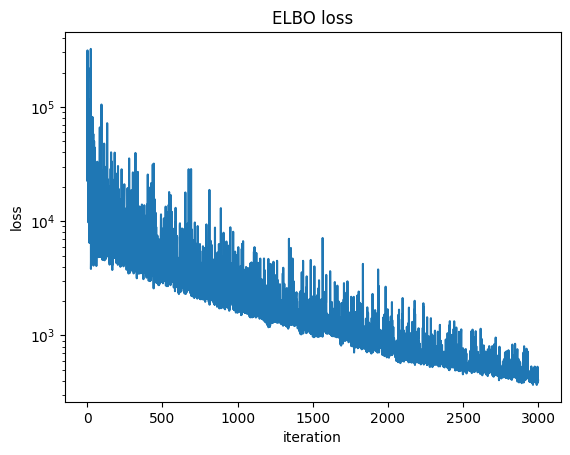

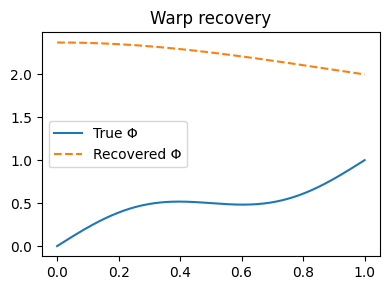

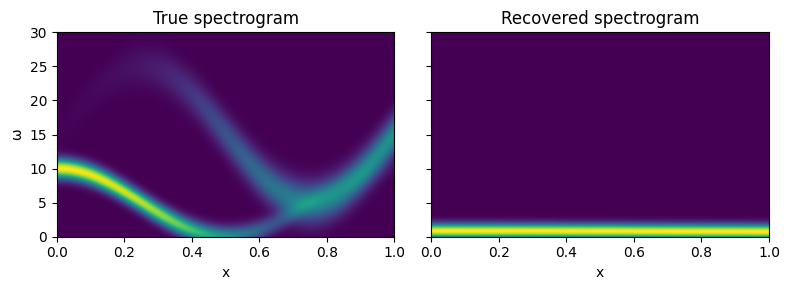

Test avg. log‑likelihood: -1.5694258


In [48]:
import jax, jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 0) Helpers
# -------------------------------------------------------------------
def safe_softplus(x):
    return jnp.where(x > 20, x, jnp.log1p(jnp.exp(x)))

# split
def train_test_split(x, y, frac=0.8):
    n = x.shape[0]
    k = int(n * frac)
    return x[:k], y[:k], x[k:], y[k:]

# -------------------------------------------------------------------
# 1) Redesigned WarpNet1D with random init & more capacity
# -------------------------------------------------------------------
class WarpNet1D:
    def __init__(self, h=16, name="warp"):
        self.h, self.name = h, name

    def __call__(self, x):
        # small noisy initialization
        W1 = numpyro.param(
            f"{self.name}_W1",
            0.1 * jax.random.normal(jax.random.PRNGKey(0), (1, self.h))
        )
        b1 = numpyro.param(f"{self.name}_b1", jnp.zeros((self.h,)))
        W2 = numpyro.param(
            f"{self.name}_W2",
            0.1 * jax.random.normal(jax.random.PRNGKey(1), (self.h, 1))
        )
        b2 = numpyro.param(f"{self.name}_b2", jnp.zeros((1,)))
        h   = jnp.tanh(x @ W1 + b1)   # (n,h)
        dx  = h @ W2 + b2             # (n,1)
        return x + dx                 # residual warp
    
class WarpNet1D:
    def __call__(self, x):
        W = numpyro.param("W", 0.5 * jax.random.normal(
                               jax.random.PRNGKey(2),(1,16)))
        b = numpyro.param("b", jnp.zeros(16))
        h = jnp.tanh(x @ W + b)              # (n,16)
        W2= numpyro.param("W2", 0.5 * jax.random.normal(
                               jax.random.PRNGKey(3),(16,1)))
        b2= numpyro.param("b2", jnp.zeros(1))
        return x + (h @ W2 + b2)             # residual

# -------------------------------------------------------------------
# 2) Spectral net (unchanged)
# -------------------------------------------------------------------
class SpectralNet:
    def __init__(self, Q, d, name="spec"):
        self.Q, self.d, self.name = Q, d, name

    def __call__(self, x):
        A  = numpyro.param(f"{self.name}_A", 0.01 * jnp.ones((self.d, self.Q)))
        b  = numpyro.param(f"{self.name}_b", jnp.zeros((self.Q,)))
        M  = numpyro.param(f"{self.name}_M", 0.1 * jnp.ones((self.Q, self.d)))
        m  = numpyro.param(f"{self.name}_m", jnp.zeros((self.Q,)))
        ls = numpyro.param(f"{self.name}_log_sigma", jnp.zeros((self.Q,)))
        logits = x @ A + b
        w  = jax.nn.softmax(logits, axis=-1)
        mu = x @ M.T + m
        σ  = 1e-3 + safe_softplus(ls)
        return w, mu, σ

# -------------------------------------------------------------------
# 3) FA‑HK kernel builder
# -------------------------------------------------------------------
def fahk_gram(x, xp, warp, spec):
    xw  = warp(x)    # (n,1)
    xpw = warp(xp)   # (m,1)
    w1, μ1, σ1 = spec(xw)
    w2, μ2, _  = spec(xpw)
    sqrtw = jnp.sqrt(w1[:,None,:] * w2[None,:,:])
    μavg  = 0.5 * (μ1[:,None,:] + μ2[None,:,:])
    Δ     = xw - xpw.T
    phase = jnp.cos(μavg * Δ[...,None])
    env   = jnp.exp(-0.5 * (Δ[...,None]**2) / (σ1**2))
    return jnp.sum(sqrtw * phase * env, axis=-1)

class FAHK1D:
    def __init__(self, Q=2):
        self.warp = WarpNet1D()
        self.spec = SpectralNet(Q, 1)

    def __call__(self, x, xp=None):
        xp = x if xp is None else xp
        return fahk_gram(x, xp, self.warp, self.spec)

# -------------------------------------------------------------------
# 4) Sparse GP model & guide
# -------------------------------------------------------------------
from jax.scipy.linalg import solve_triangular

def make_model(kernel, Z):
    def model(x, y=None):
        m = Z.shape[0]
        Kmm = kernel(Z) + 1e-4 * jnp.eye(m)
        Lmm = jnp.linalg.cholesky(Kmm)
        u_w = numpyro.sample("u_w", dist.Normal(0,1).expand([m]).to_event(1))
        u   = Lmm @ u_w
        Kmn = kernel(x, Z)
        A   = solve_triangular(Lmm, Kmn.T, lower=True)
        fmu = (A.T @ u)
        diag= kernel(x).diagonal()
        fvar= jnp.clip(diag - (A**2).sum(0), 1e-5, None)
        σn  = numpyro.sample("sigma", dist.LogNormal(-2.3, 0.3))
        numpyro.sample("obs",
                       dist.Normal(fmu, jnp.sqrt(fvar + σn**2)),
                       obs=y)
    return model

def make_guide(Z):
    def guide(x, y=None):
        m = Z.shape[0]
        loc  = numpyro.param("loc", jnp.zeros(m))
        tril = numpyro.param("tril", jnp.eye(m))
        numpyro.sample("u_w",
                       dist.MultivariateNormal(loc,
                                               scale_tril=jnp.tril(tril)))
        numpyro.sample("sigma",
                       dist.LogNormal(numpyro.param("l_mu",-2.3),
                                      numpyro.param("l_sd",0.1)))
    return guide

# -------------------------------------------------------------------
# 5) Synthetic ground truth & train/test split
# -------------------------------------------------------------------
def phi_true(x):
    return x + 0.2 * jnp.sin(2*jnp.pi*x)

def spectral_true(x, omegas):
    w1    = jax.nn.sigmoid(8 * (x - 0.5))
    w2    = 1 - w1
    mu1   = 15 + 10 * jnp.sin(2*jnp.pi*x)
    mu2   = 5  +  5 * jnp.cos(2*jnp.pi*x)
    σ1,σ2 = 2.0, 1.0
    S1 = w1[:,None] * jnp.exp(-0.5*((omegas-mu1[:,None])**2)/σ1**2)/(σ1*jnp.sqrt(2*jnp.pi))
    S2 = w2[:,None] * jnp.exp(-0.5*((omegas-mu2[:,None])**2)/σ2**2)/(σ2*jnp.sqrt(2*jnp.pi))
    return S1 + S2

key = jax.random.PRNGKey(0)
n   = 256
x   = jnp.linspace(0,1,n).reshape(-1,1)
xt  = phi_true(x)
y   = jnp.sin(4*jnp.pi*xt[:,0]) + 0.3*jax.random.normal(key,(n,))
y   = y.at[120:].add(1.0)

x_tr, y_tr, x_te, y_te = train_test_split(x, y, frac=0.8)

# inducing points
m = 32
Z = x_tr[:: x_tr.shape[0]//m]

# -------------------------------------------------------------------
# 6) SVI
# -------------------------------------------------------------------
kernel = FAHK1D(Q=2)
svi    = SVI(make_model(kernel,Z),
              make_guide(Z),
              Adam(3e-3),
              Trace_ELBO())
state  = svi.init(jax.random.PRNGKey(1), x_tr, y_tr)
losses = []
for i in range(1, 3001):
    state, loss = svi.update(state, x_tr, y_tr)
    losses.append(loss)
    if i % 500 == 0:
        print(f"{i:4d}  ELBO = {-loss:.3f}")
print("Training complete.")

plt.semilogy(losses)
plt.title("ELBO loss"); plt.xlabel("iteration"); plt.ylabel("loss")
plt.show()

# -------------------------------------------------------------------
# 7) Warp & Spectrogram recovery
# -------------------------------------------------------------------
params     = svi.get_params(state)

# recovered warp
warp_fn    = lambda xx: WarpNet1D().__call__(xx)
warp_rec   = numpyro.handlers.substitute(warp_fn, params)(x)

plt.figure(figsize=(4,3))
plt.plot(x, phi_true(x), label="True Φ")
plt.plot(x, warp_rec,    '--',   label="Recovered Φ")
plt.legend(); plt.title("Warp recovery"); plt.tight_layout()
plt.show()

# recovered spectrogram
omegas = jnp.linspace(0,30,200)
S_true = spectral_true(x[:,0], omegas)

spec_fn = lambda xx: SpectralNet(2,1)(xx)
w_rec, μ_rec, σ_rec = numpyro.handlers.substitute(spec_fn, params)(warp_rec)

S_rec = sum(
    w_rec[:,q,None]
    * jnp.exp(-0.5*((omegas-μ_rec[:,q,None])**2)/σ_rec[q]**2)
    / (σ_rec[q]*jnp.sqrt(2*jnp.pi))
    for q in range(2)
)

fig,(a1,a2)=plt.subplots(1,2,figsize=(8,3),sharey=True)
a1.imshow(S_true.T, aspect='auto', origin='lower',
          extent=[0,1,omegas[0],omegas[-1]])
a1.set(title="True spectrogram", xlabel="x", ylabel="ω")
a2.imshow(S_rec.T, aspect='auto', origin='lower',
          extent=[0,1,omegas[0],omegas[-1]])
a2.set(title="Recovered spectrogram", xlabel="x")
plt.tight_layout(); plt.show()

# -------------------------------------------------------------------
# 8) Predictive log‑likelihood on test set
# -------------------------------------------------------------------
# Build the Predictive object once:
predictive = Predictive(make_model(kernel, Z),
                        guide=make_guide(Z),
                        params=params,
                        num_samples=200)

# On the *training* inputs (to check fit):
rng1 = jax.random.PRNGKey(0)
preds_train = predictive(rng1, x_tr, y_tr)  
# preds_train["obs"] has shape (200, n_train)

# On the *test* inputs, we just set y=None:
rng2 = jax.random.PRNGKey(1)
preds_test  = predictive(rng2, x_te, None)  
obs_samps = preds_test["obs"]  # shape (S, n_te)

# compute average log‑density
import scipy.stats as ss

yhat_test = preds_test["obs"].mean(0)
σhat_test = preds_test["obs"].std(0) + 1e-6
lls = ss.norm.logpdf(y_te[None,:], loc=yhat_test, scale=σhat_test)
print("Test avg. log‑likelihood:", jnp.mean(lls))


Iter 500, ELBO -707.17
Iter 1000, ELBO -316.78
Iter 1500, ELBO -219.39
Iter 2000, ELBO -175.52
Synthetic MSE=0.180, LL=-0.565


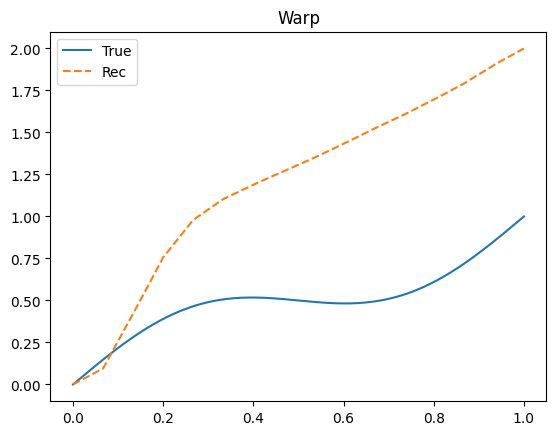

In [57]:
# nonstat_fahk_synthetic.py
# End-to-end synthetic experiments for Non-Stationary FA-HK

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from jax.scipy.linalg import solve_triangular
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# 1) Constrained Warp: Monotonic Spline Flow
# ----------------------------------------------------------------------------
class MonotonicSplineWarp:
    """
    1D monotonic warp via a piecewise-linear spline with constrained increasing knots.
    """
    def __init__(self, n_knots=16, name="warp"):  # knots on [0,1]
        self.n_knots = n_knots
        self.name = name
    def __call__(self, x):
        # x: (N,1)
        raw = numpyro.param(f"{self.name}_raw", jnp.zeros((self.n_knots,)))
        knots = jnp.linspace(0.,1.,self.n_knots)
        deltas = jax.nn.softplus(raw)
        offsets = jnp.cumsum(deltas)
        offsets = (offsets - offsets[0]) / (offsets[-1] - offsets[0] + 1e-6)
        return jax.vmap(lambda xi: jnp.interp(xi, knots, knots + offsets))(x)

# ----------------------------------------------------------------------------
# 2) Spectral Mixture: Factor-Analysed Harmonisable Kernel
# ----------------------------------------------------------------------------
class SpectralMixture:
    def __init__(self, Q, d=1, name="spec"):
        self.Q, self.d, self.name = Q, d, name
    def __call__(self, x):
        A = numpyro.param(f"{self.name}_A", 0.1 * jnp.ones((self.d, self.Q)))
        b = numpyro.param(f"{self.name}_b", jnp.zeros((self.Q,)))
        M = numpyro.param(f"{self.name}_M", 0.1 * jnp.ones((self.Q, self.d)))
        m = numpyro.param(f"{self.name}_m", jnp.zeros((self.Q,)))
        logs = numpyro.param(f"{self.name}_logsigma", jnp.zeros((self.Q,)))
        logits = jnp.dot(x, A) + b
        w = jax.nn.softmax(logits, axis=-1)
        mu = jnp.dot(x, M.T) + m
        sigma = 1e-3 + jax.nn.softplus(logs)
        return w, mu, sigma



def fahk_kernel_matrix(x, xp, warp, spec):
    xw = warp(x)
    xpw = warp(xp)
    w1, mu1, s1 = spec(xw)
    w2, mu2, _ = spec(xpw)
    sqrtw = jnp.sqrt(w1[:,None,:] * w2[None,:,:])
    mu_avg = 0.5 * (mu1[:,None,:] + mu2[None,:,:])
    delta = xw[:,None,0] - xpw[None,:,0]
    phase = jnp.cos(mu_avg * delta[:,:,None])
    env = jnp.exp(-0.5 * (delta[:,:,None]**2) / (s1[None,None,:]**2))
    return jnp.sum(sqrtw * phase * env, axis=-1)

# ----------------------------------------------------------------------------
# 3) Sparse GP Model
# ----------------------------------------------------------------------------
def build_model(Z, warp, spec):
    def model(x, y=None):
        m = Z.shape[0]
        Kmm = fahk_kernel_matrix(Z, Z, warp, spec) + 1e-6*jnp.eye(m)
        Lmm = jnp.linalg.cholesky(Kmm)
        u_w = numpyro.sample("u_w", dist.Normal(0,1).expand([m]).to_event(1))
        u = jnp.matmul(Lmm, u_w)
        Kmn = fahk_kernel_matrix(x, Z, warp, spec)
        A = solve_triangular(Lmm, Kmn.T, lower=True)
        fmu = jnp.matmul(A.T, u)
        var = fahk_kernel_matrix(x, x, warp, spec).diagonal() - jnp.sum(A**2, axis=0)
        fvar = jnp.clip(var, 1e-6, None)
        sigma = numpyro.sample("sigma", dist.LogNormal(-2.3,0.3))
        numpyro.sample("obs", dist.Normal(fmu, jnp.sqrt(fvar + sigma**2)), obs=y)
    return model

# ----------------------------------------------------------------------------
# 4) Guide: Low-rank + Diagonal
# ----------------------------------------------------------------------------
def build_guide(Z, rank=8):
    def guide(x, y=None):
        m = Z.shape[0]
        loc = numpyro.param("loc", jnp.zeros(m))
        V = numpyro.param("V", 0.01*jnp.ones((m, rank)))
        d_raw = numpyro.param("d_raw", -3*jnp.ones(m))
        tau = numpyro.param("log_tau", 0.)
        diag = jax.nn.softplus(d_raw)*jnp.exp(tau)+1e-6
        cov = jnp.matmul(V, V.T) + jnp.diag(diag)
        numpyro.sample("u_w", dist.MultivariateNormal(loc, covariance_matrix=cov))
        numpyro.sample("sigma", dist.LogNormal(numpyro.param("l_mu",-2.3), numpyro.param("l_sd",0.1)))
    return guide

# ----------------------------------------------------------------------------
# 5) Training & Evaluation
# ----------------------------------------------------------------------------
def train_svi(model, guide, x_tr, y_tr, lr=3e-3, n_iter=2000):
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    rng = jax.random.PRNGKey(0)
    state = svi.init(rng, x_tr, y_tr)
    for i in range(1, n_iter+1):
        state, loss = svi.update(state, x_tr, y_tr)
        if i % 500 == 0:
            print(f"Iter {i}, ELBO {-loss:.2f}")
    return svi.get_params(state)

def predictive(model, guide, params, x_tr, y_tr, x_te):
    pred = Predictive(model, guide=guide, params=params, num_samples=200)
    samples = pred(jax.random.PRNGKey(1), x_te, None)
    y_samps = samples['obs']
    return jnp.mean(y_samps,0), jnp.std(y_samps,0)

# ----------------------------------------------------------------------------
# 6) Synthetic Experiment
# ----------------------------------------------------------------------------
def synthetic_experiment():
    # True warp & spectrum
    phi = lambda x: x + 0.2*jnp.sin(2*jnp.pi*x)
    n=256
    x = jnp.linspace(0,1,n).reshape(-1,1)
    xw = phi(x)
    y = jnp.sin(4*jnp.pi*xw[:,0]) + 0.3*jax.random.normal(jax.random.PRNGKey(0),(n,))
    # split
    idx = jnp.arange(n)
    perm = jax.random.permutation(jax.random.PRNGKey(1), idx)
    tr, te = perm[:200], perm[200:]
    x_tr, y_tr = x[tr], y[tr]
    x_te, y_te = x[te], y[te]
    # inducing
    m=32; Z = x_tr[jnp.linspace(0,199,m,endpoint=False,dtype=int)]
    warp = MonotonicSplineWarp(n_knots=16)
    spec = SpectralMixture(Q=2)
    model = build_model(Z, warp, spec)
    guide = build_guide(Z, rank=8)
    params = train_svi(model, guide, x_tr, y_tr)
    mu, std = predictive(model, guide, params, x_tr, y_tr, x_te)
    mse = jnp.mean((mu-y_te)**2); ll=jnp.mean(dist.Normal(mu,std+1e-6).log_prob(y_te))
    print(f"Synthetic MSE={mse:.3f}, LL={ll:.3f}")
    # recovery
    warp_fn = lambda xx: MonotonicSplineWarp(16)(xx)
    w_rec = numpyro.handlers.substitute(warp_fn, params)(x)
    plt.figure(); plt.plot(x, phi(x), label='True'); plt.plot(x, w_rec, '--', label='Rec'); plt.legend(); plt.title('Warp'); plt.show()

if __name__ == "__main__":
    jax.config.update('jax_enable_x64', True)
    synthetic_experiment()


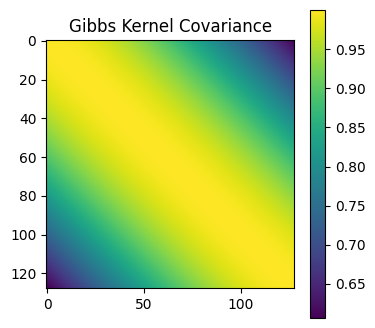

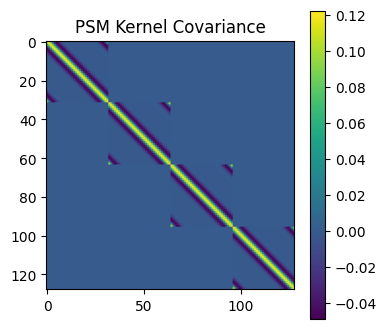

patch1d: True
patch2d: True


In [79]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1-D Patch‑Wise Spectral Mixture with custom JVP
# ---------------------------------------------------------------------------
@jax.custom_jvp
def patchwise_specmix_1d(x: jnp.ndarray, S: jnp.ndarray) -> jnp.ndarray:
    """
    1D FFT-based convolution with custom JVP:
      y = IFFT(FFT(x) * S)
    where S is the real PSD for a single patch.
    """
    Xf = jnp.fft.rfft(x, axis=-1)
    return jnp.fft.irfft(Xf * S, n=x.shape[-1], axis=-1)

@patchwise_specmix_1d.defjvp
def patchwise_specmix_1d_jvp(primals, tangents):
    x, S = primals
    dx, dS = tangents
    Xf = jnp.fft.rfft(x, axis=-1)
    dXf = jnp.fft.rfft(dx, axis=-1) if dx is not None else 0.0
    Yf = Xf * S
    dYf = dXf * S + Xf * dS
    y = jnp.fft.irfft(Yf, n=x.shape[-1], axis=-1)
    dy = jnp.fft.irfft(dYf, n=x.shape[-1], axis=-1)
    return y, dy

class PatchWiseSpectralMixture1D:
    """
    1-D patch-wise spectral mixture convolution.
    w, mu, sigma have shapes (n_patches, Q).
    """
    def __init__(self, patch_size: int, w: jnp.ndarray, mu: jnp.ndarray, sigma: jnp.ndarray):
        self.patch_size = patch_size
        self.n_patches = w.shape[0]
        self.Q = w.shape[1]
        self.w = w
        self.mu = mu
        self.sigma = sigma

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, N = x.shape
        assert N == self.patch_size * self.n_patches
        freqs = jnp.fft.rfftfreq(self.patch_size)
        patches = []
        for p in range(self.n_patches):
            xp = x[:, p*self.patch_size:(p+1)*self.patch_size]
            # build PSD for patch p
            S = jnp.zeros_like(freqs)
            for q in range(self.Q):
                S = S + self.w[p, q] * (
                    jnp.exp(-0.5 * ((freqs - self.mu[p, q]) / self.sigma[p, q])**2)
                  + jnp.exp(-0.5 * ((freqs + self.mu[p, q]) / self.sigma[p, q])**2)
                )
            S = S + 1e-6  # floor
            yp = patchwise_specmix_1d(xp, S)
            patches.append(yp)
        return jnp.concatenate(patches, axis=-1)

# ---------------------------------------------------------------------------
# 2-D Patch‑Wise Spectral Mixture with custom JVP
# ---------------------------------------------------------------------------
@jax.custom_jvp
def patchwise_specmix_2d(x: jnp.ndarray, S: jnp.ndarray) -> jnp.ndarray:
    """
    2D FFT-based convolution with custom JVP:
      y = IFFT2(FFT2(x) * S)
    where S is the real PSD for a single patch.
    x: (B, ph, pw), S: (ph, pw)
    returns y: (B, ph, pw)
    """
    Xf = jnp.fft.fftn(x, axes=(-2, -1))
    return jnp.fft.ifftn(Xf * S[None, :, :], axes=(-2, -1)).real

@patchwise_specmix_2d.defjvp
def patchwise_specmix_2d_jvp(primals, tangents):
    x, S = primals
    dx, dS = tangents
    Xf = jnp.fft.fftn(x, axes=(-2, -1))
    dXf = jnp.fft.fftn(dx, axes=(-2, -1)) if dx is not None else 0.0
    Yf = Xf * S[None, :, :]
    dYf = dXf * S[None, :, :] + Xf * dS[None, :, :]
    y = jnp.fft.ifftn(Yf, axes=(-2, -1)).real
    dy = jnp.fft.ifftn(dYf, axes=(-2, -1)).real
    return y, dy

class PatchWiseSpectralMixture2D:
    """
    2-D patch-wise spectral mixture convolution.
    w, mu, sigma have shapes (n_patches_h, n_patches_w, Q).
    """
    def __init__(self, patch_h: int, patch_w: int,
                 w: jnp.ndarray, mu: jnp.ndarray, sigma: jnp.ndarray):
        # w: (nh, nw, Q), mu,sigma same
        self.patch_h = patch_h
        self.patch_w = patch_w
        self.nh, self.nw, self.Q = w.shape
        self.w = w
        self.mu = mu
        self.sigma = sigma

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, H, W = x.shape
        assert H == self.nh * self.patch_h and W == self.nw * self.patch_w
        # frequency grids
        fy = jnp.fft.fftfreq(self.patch_h)
        fx = jnp.fft.fftfreq(self.patch_w)
        FY, FX = jnp.meshgrid(fy, fx, indexing='ij')
        patches = []
        for i in range(self.nh):
            row = []
            for j in range(self.nw):
                sub = x[:, i*self.patch_h:(i+1)*self.patch_h,
                         j*self.patch_w:(j+1)*self.patch_w]
                # build PSD
                S = jnp.zeros_like(FY)
                for q in range(self.Q):
                    gauss = jnp.exp(-0.5 * (((FY - self.mu[i,j,q,0]) / self.sigma[i,j,q,0])**2
                                           + ((FX - self.mu[i,j,q,1]) / self.sigma[i,j,q,1])**2))
                    gauss_m = jnp.exp(-0.5 * (((FY + self.mu[i,j,q,0]) / self.sigma[i,j,q,0])**2
                                             + ((FX + self.mu[i,j,q,1]) / self.sigma[i,j,q,1])**2))
                    S = S + self.w[i,j,q] * (gauss + gauss_m)
                S = S + 1e-6
                ypatch = patchwise_specmix_2d(sub, S)
                row.append(ypatch)
            patches.append(jnp.concatenate(row, axis=2))
        return jnp.concatenate(patches, axis=1)

# ---------------------------------------------------------------------------
# Synthetic Data & Visualization Utilities
# ---------------------------------------------------------------------------
def generate_chirp(n: int = 1024, f0: float = 5., f1: float = 50.) -> jnp.ndarray:
    """Generate a linear chirp on [0,1]."""
    t = jnp.linspace(0.,1.,n)
    k = f0 + (f1-f0)*t
    phase = 2*jnp.pi*jnp.cumsum(k)/n
    return jnp.sin(phase)


def plot_covariance(K: jnp.ndarray, title: str = "Covariance"):
    plt.figure(figsize=(4,4))
    plt.imshow(K, cmap='viridis')
    plt.colorbar(); plt.title(title); plt.show()

# ---------------------------------------------------------------------------
# Demo: visualize 1D covariance for Gibbs and PSM
# ---------------------------------------------------------------------------
def demo_1d_kernels():
    # positions
    n = 128; t = jnp.linspace(0.,1.,n)
    # Gibbs lengthscale
    log_l = 0. * jnp.ones(n)  # constant lengthscale
    l = jnp.exp(log_l)
    xi = t[:,None]; xj = t[None,:]
    li = l[:,None]; lj = l[None,:]
    denom = li**2 + lj**2 + 1e-6
    K_gibbs = jnp.sqrt(2*li*lj/denom)*jnp.exp(-(xi-xj)**2/denom)
    plot_covariance(K_gibbs, title="Gibbs Kernel Covariance")

    # PSM: 4 patches, Q=2
    patch_size = 32; n_patches = n//patch_size; Q = 2
    w = jnp.ones((n_patches,Q)) / Q
    mu = jnp.stack([jnp.array([0.1,0.4])]*n_patches)
    sigma = 0.05*jnp.ones_like(mu)
    psm = PatchWiseSpectralMixture1D(patch_size, w, mu, sigma)
    # build covariance block-wise
    Ks = []
    for p in range(n_patches):
        # compute patch covariance via IFFT of PSD
        freqs = jnp.fft.rfftfreq(patch_size)
        S = w[p,0]*jnp.exp(-0.5*((freqs-mu[p,0])/sigma[p,0])**2)
        + w[p,1]*jnp.exp(-0.5*((freqs-mu[p,1])/sigma[p,1])**2)
        ps = jnp.fft.irfft(S, n=patch_size)
        # Toeplitz covariance
        Kp = jax.scipy.linalg.toeplitz(ps)
        Ks.append(Kp)
    K_psm = jax.scipy.linalg.block_diag(*Ks)
    plot_covariance(K_psm, title="PSM Kernel Covariance")

# helper: finite‐difference directional derivative
def fd_dot(fun, primals, tangents, eps=1e-3):
    primals_p = [p + eps*dp if dp is not None else p for p,dp in zip(primals, tangents)]
    primals_m = [p - eps*dp if dp is not None else p for p,dp in zip(primals, tangents)]
    y_p = fun(*primals_p).sum()
    y_m = fun(*primals_m).sum()
    return (y_p - y_m) / (2*eps)

# 1) patchwise_specmix_1d
def test_patch1d():
    key = jax.random.PRNGKey(0)
    batch, patch = 3, 16
    x = jax.random.normal(key, (batch, patch))
    # uniform PSD
    freqs = jnp.fft.rfftfreq(patch)
    S = jnp.ones_like(freqs)
    dx = jax.random.normal(key, x.shape) * 1e-3
    dS = jax.random.normal(key, S.shape) * 1e-3

    y, y_dot = jax.jvp(lambda x,S: patchwise_specmix_1d(x,S).sum(),
                      (x, S), (dx, dS))
    fd = fd_dot(patchwise_specmix_1d, (x,S), (dx,dS))
    print("patch1d:", jnp.allclose(y_dot, fd, rtol=1e-3, atol=1e-3))

# 2) patchwise_specmix_2d
def test_patch2d():
    key = jax.random.PRNGKey(1)
    batch, ph, pw = 2, 8, 8
    x = jax.random.normal(key, (batch, ph, pw))
    # uniform PSD
    S = jnp.ones((ph,pw))
    dx = jax.random.normal(key, x.shape) * 1e-3
    dS = jax.random.normal(key, S.shape) * 1e-3

    y, y_dot = jax.jvp(lambda x,S: patchwise_specmix_2d(x,S).sum(),
                      (x, S), (dx, dS))
    fd = fd_dot(patchwise_specmix_2d, (x,S), (dx,dS))
    print("patch2d:", jnp.allclose(y_dot, fd, rtol=1e-3, atol=1e-3))

# Run demo
if __name__ == '__main__':
    demo_1d_kernels()
    test_patch1d()
    test_patch2d()


In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

# ---------------------------------------------------------------------------
# Custom-JVP primitives for spectral mixture convolution
# ---------------------------------------------------------------------------
@jax.custom_jvp
def patchwise_specmix_1d(x: jnp.ndarray, S: jnp.ndarray) -> jnp.ndarray:
    """
    1D FFT-based convolution with custom JVP:
      y = IFFT(FFT(x) * S)
    where S is the real PSD for a single patch.
    x: (B, P), S: (P/2+1,)
    returns y: (B, P)
    """
    Xf = jnp.fft.rfft(x, axis=-1)
    return jnp.fft.irfft(Xf * S, n=x.shape[-1], axis=-1)

@patchwise_specmix_1d.defjvp
def patchwise_specmix_1d_jvp(primals, tangents):
    x, S = primals
    dx, dS = tangents
    Xf = jnp.fft.rfft(x, axis=-1)
    dXf = jnp.fft.rfft(dx, axis=-1) if dx is not None else 0.0
    Yf = Xf * S
    dYf = dXf * S + Xf * dS
    y = jnp.fft.irfft(Yf, n=x.shape[-1], axis=-1)
    dy = jnp.fft.irfft(dYf, n=x.shape[-1], axis=-1)
    return y, dy

@jax.custom_jvp
def patchwise_specmix_2d(x: jnp.ndarray, S: jnp.ndarray) -> jnp.ndarray:
    """
    2D FFT-based convolution with custom JVP:
      y = IFFT2(FFT2(x) * S)
    where S is the real PSD for a single patch.
    x: (B, ph, pw), S: (ph, pw)
    returns y: (B, ph, pw)
    """
    Xf = jnp.fft.fftn(x, axes=(-2, -1))
    return jnp.fft.ifftn(Xf * S[None, :, :], axes=(-2, -1)).real

@patchwise_specmix_2d.defjvp
def patchwise_specmix_2d_jvp(primals, tangents):
    x, S = primals
    dx, dS = tangents
    Xf = jnp.fft.fftn(x, axes=(-2, -1))
    dXf = jnp.fft.fftn(dx, axes=(-2, -1)) if dx is not None else 0.0
    Yf = Xf * S[None, :, :]
    dYf = dXf * S[None, :, :] + Xf * dS[None, :, :]
    y = jnp.fft.ifftn(Yf, axes=(-2, -1)).real
    dy = jnp.fft.ifftn(dYf, axes=(-2, -1)).real
    return y, dy

# ---------------------------------------------------------------------------
# 1-D Patch‑Wise Spectral Mixture Layer (custom JVP)
# ---------------------------------------------------------------------------
class PatchWiseSpectralMixture1DLayer:
    """
    1-D non-overlapping patch-wise spectral-mixture convolution using
    a custom JVP for efficient differentiation.

    Hyper-parameters per patch p and mixture q:
        w[p,q]      = softmax(logits_w)[p,q]
        mu[p,q]     = 0.5 * sigmoid(raw_mu)[p,q]
        sigma[p,q]  = softplus(raw_sigma)[p,q] + 1e-3
    """
    def __init__(self, in_features: int, patch_size: int,
                 n_mixtures: int = 3, name: str = "patch1d"):    
        assert in_features % patch_size == 0, \
            "in_features must be divisible by patch_size"
        self.N = in_features
        self.P = patch_size
        self.M = n_mixtures
        self.n_patches = in_features // patch_size
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, N = x.shape
        assert N == self.N, f"Expected input features {self.N}, got {N}"

        # Learnable parameters
        logits_w = numpyro.param(f"{self.name}_logits_w",
                                  jnp.zeros((self.n_patches, self.M)))
        raw_mu = numpyro.param(f"{self.name}_raw_mu",
                                0.01 * jax.random.normal(
                                    numpyro.prng_key(),
                                    (self.n_patches, self.M)
                                ))
        raw_sigma = numpyro.param(f"{self.name}_raw_sigma",
                                   jnp.zeros((self.n_patches, self.M)))

        # Constrain
        w = jax.nn.softmax(logits_w, axis=-1)
        mu = 0.5 * jax.nn.sigmoid(raw_mu)
        sigma = jax.nn.softplus(raw_sigma) + 1e-3

        freqs = jnp.fft.rfftfreq(self.P)
        patches = []
        for p in range(self.n_patches):
            xp = x[:, p*self.P:(p+1)*self.P]
            # Build PSD
            S = jnp.zeros_like(freqs)
            for q in range(self.M):
                S = S + w[p, q] * (
                    jnp.exp(-0.5 * ((freqs - mu[p,q]) / sigma[p,q])**2)
                  + jnp.exp(-0.5 * ((freqs + mu[p,q]) / sigma[p,q])**2)
                )
            S = S + 1e-6
            # Apply custom JVP conv
            yp = patchwise_specmix_1d(xp, S)
            patches.append(yp)

        return jnp.concatenate(patches, axis=-1)

# ---------------------------------------------------------------------------
# 2-D Patch‑Wise Spectral Mixture Layer (custom JVP)
# ---------------------------------------------------------------------------
class PatchWiseSpectralMixture2DLayer:
    """
    2-D non-overlapping patch-wise spectral-mixture convolution using
    a custom JVP for efficient differentiation.

    Hyper-parameters per patch index idx and mixture q:
        w[idx,q]      = softmax(logits_w)[idx,q]
        mu[idx,q,:]   = 0.5 * sigmoid(raw_mu)[idx,q,:]
        sigma[idx,q,:]= softplus(raw_sigma)[idx,q,:] + 1e-3
    """
    def __init__(self, H: int, W: int, patch_h: int, patch_w: int,
                 n_mixtures: int = 3, name: str = "patch2d"):
        assert H % patch_h == 0 and W % patch_w == 0, \
            "Height and width must be divisible by patch size"
        self.H, self.W = H, W
        self.ph, self.pw = patch_h, patch_w
        self.nh, self.nw = H // patch_h, W // patch_w
        self.M = n_mixtures
        self.name = name
        self.npatch = self.nh * self.nw

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        B, H, W = x.shape
        assert (H, W) == (self.H, self.W), \
            f"Expected input shape ({self.H}, {self.W}), got ({H}, {W})"

        # Learnable parameters
        logits_w = numpyro.param(f"{self.name}_logits_w",
                                  jnp.zeros((self.npatch, self.M)))
        raw_mu = numpyro.param(f"{self.name}_raw_mu",
                                0.01 * jax.random.normal(
                                    numpyro.prng_key(),
                                    (self.npatch, self.M, 2)
                                ))
        raw_sigma = numpyro.param(f"{self.name}_raw_sigma",
                                   jnp.zeros((self.npatch, self.M, 2)))

        w = jax.nn.softmax(logits_w, axis=-1)
        mu = 0.5 * jax.nn.sigmoid(raw_mu)
        sigma = jax.nn.softplus(raw_sigma) + 1e-3

        # Frequency grids
        fy = jnp.fft.fftfreq(self.ph)
        fx = jnp.fft.fftfreq(self.pw)
        FY, FX = jnp.meshgrid(fy, fx, indexing='ij')

        out_rows = []
        idx = 0
        for i in range(self.nh):
            row_patches = []
            for j in range(self.nw):
                sub = x[:, i*self.ph:(i+1)*self.ph,
                         j*self.pw:(j+1)*self.pw]

                # Build PSD
                S = jnp.zeros_like(FY)
                for q in range(self.M):
                    dy = (FY - mu[idx, q, 0]) / sigma[idx, q, 0]
                    dx = (FX - mu[idx, q, 1]) / sigma[idx, q, 1]
                    gauss = jnp.exp(-0.5 * (dy**2 + dx**2))
                    dy_m = (FY + mu[idx, q, 0]) / sigma[idx, q, 0]
                    dx_m = (FX + mu[idx, q, 1]) / sigma[idx, q, 1]
                    gauss_m = jnp.exp(-0.5 * (dy_m**2 + dx_m**2))
                    S = S + w[idx, q] * (gauss + gauss_m)
                S = S + 1e-6

                # Apply custom JVP conv
                y_patch = patchwise_specmix_2d(sub, S)
                row_patches.append(y_patch)
                idx += 1
            out_rows.append(jnp.concatenate(row_patches, axis=2))

        return jnp.concatenate(out_rows, axis=1)

# ---------------------------------------------------------------------------
# Models
# ---------------------------------------------------------------------------
def patch1d_model(X, y=None):
    out = PatchWiseSpectralMixture1DLayer(
        in_features=64, patch_size=16, n_mixtures=3, name="patch1d"
    )(X)
    W = numpyro.sample(
        "W", dist.Normal(0,1).expand([64,1]).to_event(2)
    )
    b = numpyro.sample(
        "b", dist.Normal(0,1).expand([1]).to_event(1)
    )
    logits = jnp.squeeze(out @ W + b)
    numpyro.sample(
        "obs", dist.Bernoulli(logits=logits), obs=y
    )


def patch2d_model(X, y=None):
    out = PatchWiseSpectralMixture2DLayer(
        H=32, W=32, patch_h=8, patch_w=8, n_mixtures=3, name="patch2d"
    )(X)
    h = out.reshape(out.shape[0], -1)
    W = numpyro.sample(
        "W", dist.Normal(0,1).expand([h.shape[-1],2]).to_event(2)
    )
    b = numpyro.sample(
        "b", dist.Normal(0,1).expand([2]).to_event(1)
    )
    logits = h @ W + b
    numpyro.sample(
        "obs", dist.Categorical(logits=logits), obs=y
    )

# ---------------------------------------------------------------------------
# Custom hierarchical guides grouping W by patch
# ---------------------------------------------------------------------------
def patch1d_hierarchical_guide(X, y=None):
    # Group W by 4 non-overlapping patches of size 16
    in_features, patch_size = 64, 16
    n_patches = in_features // patch_size
    # variational group means and log-scales
    mu_group = numpyro.param("mu_group", jnp.zeros((n_patches,1)))
    rho_group = numpyro.param("rho_group", -3 * jnp.ones((n_patches,1)))
    sigma_group = jnp.exp(rho_group)
    # assign each weight index to a group
    groups = jnp.repeat(jnp.arange(n_patches), patch_size)
    loc = mu_group[groups]     # shape (64,1)
    scale = sigma_group[groups]
    W = numpyro.sample("W", dist.Normal(loc, scale).to_event(2))
    # simple factorized guide for bias
    b_loc = numpyro.param("b_loc", jnp.zeros((1,)))
    b_rho = numpyro.param("b_rho", -3.0)
    b_scale = jnp.exp(b_rho)
    b = numpyro.sample("b", dist.Normal(b_loc, b_scale).to_event(1))
    return {"W": W, "b": b}


def patch2d_hierarchical_guide(X, y=None):
    # Group W by 16 patches of size 8x8
    H, W_, ph, pw = 32, 32, 8, 8
    nh, nw = H // ph, W_ // pw
    n_patches = nh * nw
    patch_size = ph * pw
    mu_group = numpyro.param("mu_group", jnp.zeros((n_patches,1)))
    rho_group = numpyro.param("rho_group", -3 * jnp.ones((n_patches,1)))
    sigma_group = jnp.exp(rho_group)
    groups = jnp.repeat(jnp.arange(n_patches), patch_size)
    # W shape is (1024,2)
    loc = mu_group[groups]      # (1024,1)
    scale = sigma_group[groups]
    # tile to match two output classes
    loc = jnp.tile(loc, (1,2))  # (1024,2)
    scale = jnp.tile(scale, (1,2))
    W = numpyro.sample("W", dist.Normal(loc, scale).to_event(2))
    b_loc = numpyro.param("b_loc", jnp.zeros((2,)))
    b_rho = numpyro.param("b_rho", -3 * jnp.ones((2,)))
    b_scale = jnp.exp(b_rho)
    b = numpyro.sample("b", dist.Normal(b_loc, b_scale).to_event(1))
    return {"W": W, "b": b}

Patch Mixture 1D Auto-Guide
Step 100 ELBO: 289.245
Step 200 ELBO: 156.645
Step 300 ELBO: 131.584
Step 400 ELBO: 125.268
Step 500 ELBO: 120.390
Step 600 ELBO: 123.566
Step 700 ELBO: 115.921
Step 800 ELBO: 113.892
Step 900 ELBO: 116.654
Step 1000 ELBO: 118.088
Patch Mixture 1D Custom-Guide
Step 100 ELBO: 185.027
Step 200 ELBO: 143.914
Step 300 ELBO: 118.660
Step 400 ELBO: 79.246
Step 500 ELBO: 75.590
Step 600 ELBO: 76.106
Step 700 ELBO: 75.543
Step 800 ELBO: 75.552
Step 900 ELBO: 76.756
Step 1000 ELBO: 75.665
Patch Mixture 2D Auto-Guide
Step 100 ELBO: 3324.933
Step 200 ELBO: 2464.738
Step 300 ELBO: 1626.656
Step 400 ELBO: 1228.734
Step 500 ELBO: 689.919
Step 600 ELBO: 773.211
Step 700 ELBO: 623.894
Step 800 ELBO: 718.070
Step 900 ELBO: 513.364
Step 1000 ELBO: 604.357
Patch Mixture 2D Custom-Guide
Step 100 ELBO: 3367.208
Step 200 ELBO: 1536.328
Step 300 ELBO: 330.532
Step 400 ELBO: 92.622
Step 500 ELBO: 94.744
Step 600 ELBO: 89.429
Step 700 ELBO: 90.944
Step 800 ELBO: 91.629
Step 900 ELBO

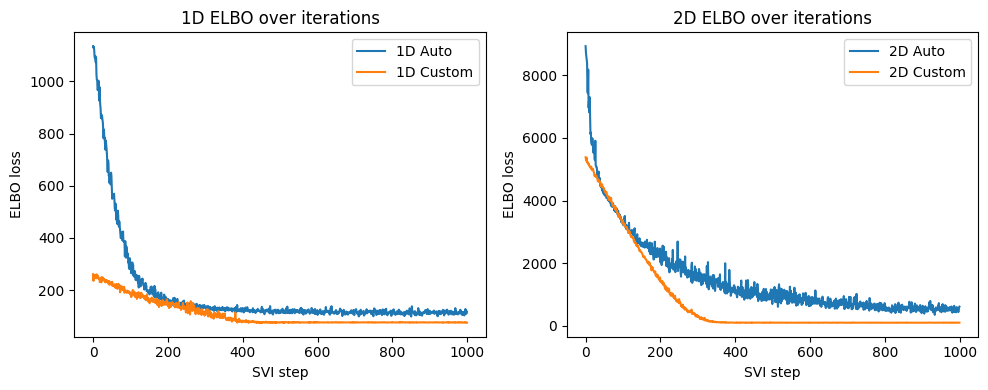

In [4]:
# End-to-end SVI comparison script for 1D and 2D spectral‐mixture models

import time
import jax
import jax.numpy as jnp
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLowRankMultivariateNormal
from numpyro.optim import Adam
import pandas as pd
import matplotlib.pyplot as plt

def run_svi(model, guide, X, y, n_steps=1000, rng_key=None):
    svi = SVI(model, guide, Adam(1e-2), Trace_ELBO())
    state = svi.init(rng_key, X, y)
    losses = []
    t0 = time.time()
    for i in range(n_steps):
        state, loss = svi.update(state, X, y)
        losses.append(loss)
        if (i+1) % 100 == 0:
            print(f"Step {i+1} ELBO: {loss:.3f}")
    t1 = time.time()
    return jnp.array(losses), t1 - t0

# Generate synthetic data
key = jax.random.PRNGKey(0)
X1 = jax.random.normal(key, (128, 64))
y1 = jax.random.bernoulli(key, p=0.3, shape=(128,))

key2 = jax.random.PRNGKey(1)
X2 = jax.random.normal(key2, (128, 32, 32))
y2 = jax.random.randint(key2, (128,), 0, 2)

# Run experiments
results = []

# 1D: Auto‐guide
print("Patch Mixture 1D Auto-Guide")
loss_auto_1d, time_auto_1d = run_svi(
    patch1d_model,
    AutoLowRankMultivariateNormal(patch1d_model),
    X1, y1,
    n_steps=1000,
    rng_key=jax.random.PRNGKey(42),
)
results.append(("1D", "auto", float(loss_auto_1d[-1]), time_auto_1d))

# 1D: Custom hierarchical guide
print("Patch Mixture 1D Custom-Guide")
loss_custom_1d, time_custom_1d = run_svi(
    patch1d_model,
    patch1d_hierarchical_guide,
    X1, y1,
    n_steps=1000,
    rng_key=jax.random.PRNGKey(43),
)
results.append(("1D", "custom", float(loss_custom_1d[-1]), time_custom_1d))

# 2D: Auto‐guide
print("Patch Mixture 2D Auto-Guide")
loss_auto_2d, time_auto_2d = run_svi(
    patch2d_model,
    AutoLowRankMultivariateNormal(patch2d_model),
    X2, y2,
    n_steps=1000,
    rng_key=jax.random.PRNGKey(44),
)
results.append(("2D", "auto", float(loss_auto_2d[-1]), time_auto_2d))

# 2D: Custom hierarchical guide
print("Patch Mixture 2D Custom-Guide")
loss_custom_2d, time_custom_2d = run_svi(
    patch2d_model,
    patch2d_hierarchical_guide,
    X2, y2,
    n_steps=1000,
    rng_key=jax.random.PRNGKey(45),
)
results.append(("2D", "custom", float(loss_custom_2d[-1]), time_custom_2d))

# Summarize in a DataFrame
df = pd.DataFrame(results, columns=["Model", "Guide", "Final_ELBO", "Time_sec"])
print(df)

# Plot ELBO curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(loss_auto_1d, label="1D Auto")
plt.plot(loss_custom_1d, label="1D Custom")
plt.title("1D ELBO over iterations")
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss_auto_2d, label="2D Auto")
plt.plot(loss_custom_2d, label="2D Custom")
plt.title("2D ELBO over iterations")
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.legend()

plt.tight_layout()
plt.show()


Step: 100 ELBO: 98999.055 
Step: 200 ELBO: 114892.391 
Step: 300 ELBO: 85970.070 
Step: 400 ELBO: 81145.789 
Step: 500 ELBO: 65101.480 
Step: 600 ELBO: 62632.914 
Step: 700 ELBO: 56546.992 
Step: 800 ELBO: 53894.301 
Step: 900 ELBO: 51941.195 
Step: 1000 ELBO: 49305.562 
Step: 1100 ELBO: 47189.141 
Step: 1200 ELBO: 44747.305 
Step: 1300 ELBO: 40645.277 
Step: 1400 ELBO: 39741.984 
Step: 1500 ELBO: 34013.766 
Step: 1600 ELBO: 34542.516 
Step: 1700 ELBO: 31985.375 
Step: 1800 ELBO: 26695.164 
Step: 1900 ELBO: 24219.666 
Step: 2000 ELBO: 21620.758 
Step: 100 ELBO: 45708.402 
Step: 200 ELBO: 40019.320 
Step: 300 ELBO: 39296.141 
Step: 400 ELBO: 31467.299 
Step: 500 ELBO: 26678.781 
Step: 600 ELBO: 26652.611 
Step: 700 ELBO: 25330.551 
Step: 800 ELBO: 19304.326 
Step: 900 ELBO: 14823.210 
Step: 1000 ELBO: 14717.760 
Step: 1100 ELBO: 12687.286 
Step: 1200 ELBO: 8377.943 
Step: 1300 ELBO: 8883.874 
Step: 1400 ELBO: 10942.282 
Step: 1500 ELBO: 2288.184 
Step: 1600 ELBO: 4272.516 
Step: 1700 EL

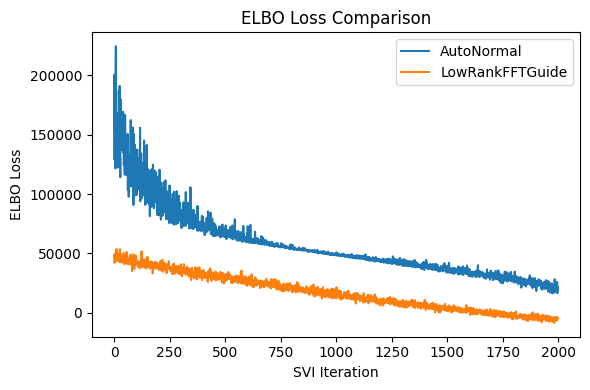

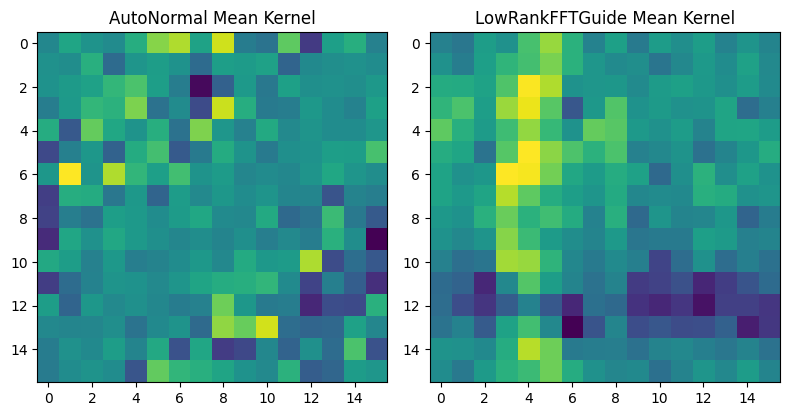

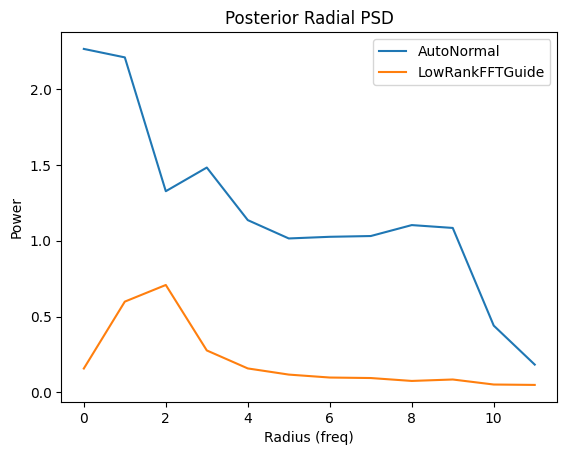

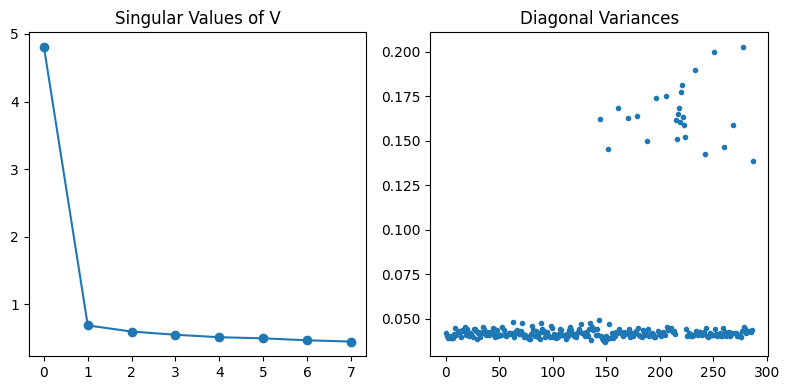

Test MSE - AutoNormal: 0.3978, LowRankFFTGuide: 0.0945


In [9]:
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal, AutoGuideList
from numpyro.infer.initialization import init_to_feasible
from numpyro.handlers import block
import matplotlib.pyplot as plt

from quantbayes.bnn.layers import SpectralPowerLawConv2d
from quantbayes.bnn.guide import LowRankFFTGuide

# 1) Synthetic dataset generation
def create_synthetic_dataset(num_samples, H, W, true_kernel, noise_std=0.1, seed=0):
    np.random.seed(seed)
    X = np.random.randn(num_samples, H, W)
    Kh, Kw = true_kernel.shape
    pad_h = H - Kh
    pad_w = W - Kw
    K_pad = np.pad(true_kernel, ((0,pad_h),(0,pad_w)))
    K_fft = np.fft.fft2(K_pad)
    X_fft = np.fft.fft2(X, axes=(1,2))
    Y = np.fft.ifft2(X_fft * K_fft[None,:,:], axes=(1,2)).real
    Y += noise_std * np.random.randn(*Y.shape)
    return jnp.array(X), jnp.array(Y)

def gaussian_kernel(size=9, sigma=2.0):
    ax = np.linspace(-(size-1)/2., (size-1)/2., size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    return kernel / kernel.sum()

# 3) Model: spectral convolution regression
def conv_regression_model(X, Y=None):
    N, H, W = X.shape
    conv = SpectralPowerLawConv2d(H, W, H_pad=H, W_pad=W)
    preds = conv(X)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(preds, sigma).to_event(2), obs=Y)

# 4) SVI runner
def run_svi_experiment(X_train, Y_train, guide, num_steps=2000, lr=1e-3):
    svi = SVI(conv_regression_model, guide, Adam(lr), Trace_ELBO())
    state = svi.init(jax.random.PRNGKey(0), X_train, Y_train)
    losses = []
    for i in range(num_steps):
        state, loss = svi.update(state, X_train, Y_train)
        losses.append(loss)
        if (i+1) % 100 == 0:
            print(f"Step: {i+1} ELBO: {loss:.3f} ")
    params = svi.get_params(state)
    return params, np.array(losses)

# 5) Radial PSD utility
def radial_psd(fft_coeffs, H, W, bin_size=1.0):
    fx = np.fft.fftfreq(H) * H
    fy = np.fft.fftfreq(W) * W
    U, V = np.meshgrid(fx, fy, indexing='ij')
    R = np.sqrt(U**2 + V**2).flatten()
    P = np.abs(fft_coeffs)**2
    P = P.reshape(P.shape[0], -1)
    r_max = R.max()
    bins = np.arange(0, r_max + bin_size, bin_size)
    radial = np.zeros((P.shape[0], len(bins)-1))
    for i in range(len(bins)-1):
        mask = (R >= bins[i]) & (R < bins[i+1])
        radial[:, i] = P[:, mask].mean(axis=1)
    return bins[:-1], radial

# 6) Main experiment pipeline
def main():
    H, W = 16, 16
    true_k = gaussian_kernel(size=9, sigma=2.0)
    X, Y = create_synthetic_dataset(200, H, W, true_k)
    X_train, Y_train = X[:160], Y[:160]
    X_test, Y_test = X[160:], Y[160:]

    # a) AutoNormal guide
    guide_auto = AutoNormal(conv_regression_model)
    params_auto, losses_auto = run_svi_experiment(X_train, Y_train, guide_auto)

    # b) LowRankFFTGuide + AutoNormal for rest
    guide_lr = AutoGuideList(conv_regression_model)
    guide_lr.append(
        LowRankFFTGuide(conv_regression_model, prefix="spectral_pw", H_pad=H, W_pad=W, rank=8)
    )
    guide_lr.append(
        AutoNormal(
            block(conv_regression_model, hide=["spectral_pw_real", "spectral_pw_imag", "obs"]),
            init_loc_fn=init_to_feasible,
        )
    )
    params_lr, losses_lr = run_svi_experiment(X_train, Y_train, guide_lr)

    # Plot ELBO losses
    plt.figure(figsize=(6,4))
    plt.plot(losses_auto, label="AutoNormal")
    plt.plot(losses_lr,   label="LowRankFFTGuide")
    plt.xlabel("SVI Iteration")
    plt.ylabel("ELBO Loss")
    plt.legend()
    plt.title("ELBO Loss Comparison")
    plt.tight_layout(); plt.show()

    # Posterior predictive kernel sampling
    num_samples = 50
    pred_auto = Predictive(
        conv_regression_model,
        guide=guide_auto,
        params=params_auto,
        num_samples=num_samples,
        return_sites=["spectral_pw_real","spectral_pw_imag"]
    )
    samples_auto = pred_auto(jax.random.PRNGKey(1), X_train)

    pred_lr = Predictive(
        conv_regression_model,
        guide=guide_lr,
        params=params_lr,
        num_samples=num_samples,
        return_sites=["spectral_pw_real","spectral_pw_imag"]
    )
    samples_lr = pred_lr(jax.random.PRNGKey(2), X_train)

    fft_auto = samples_auto["spectral_pw_real"] + 1j * samples_auto["spectral_pw_imag"]
    fft_lr   = samples_lr["spectral_pw_real"]   + 1j * samples_lr["spectral_pw_imag"]
    spatial_auto = np.fft.ifft2(fft_auto, axes=(1,2)).real
    spatial_lr   = np.fft.ifft2(fft_lr,   axes=(1,2)).real
    mean_k_auto = spatial_auto.mean(axis=0)
    mean_k_lr   = spatial_lr.mean(axis=0)

    # Plot posterior mean kernels
    fig, axs = plt.subplots(1,2,figsize=(8,4))
    axs[0].imshow(mean_k_auto, cmap='viridis')
    axs[0].set_title('AutoNormal Mean Kernel')
    axs[1].imshow(mean_k_lr, cmap='viridis')
    axs[1].set_title('LowRankFFTGuide Mean Kernel')
    plt.tight_layout(); plt.show()

    # Radial PSD comparison
    B_auto, R_auto = radial_psd(fft_auto, H, W)
    B_lr,   R_lr   = radial_psd(fft_lr,   H, W)
    plt.figure()
    plt.plot(B_auto, R_auto.mean(axis=0), label='AutoNormal')
    plt.plot(B_lr,   R_lr.mean(axis=0),   label='LowRankFFTGuide')
    plt.xlabel('Radius (freq)')
    plt.ylabel('Power')
    plt.legend(); plt.title('Posterior Radial PSD')
    plt.show()

    # Low‑Rank guide diagnostics
    V = params_lr['spectral_pw_joint_V']
    d_raw = params_lr['spectral_pw_joint_d_raw']
    log_tau = params_lr['spectral_pw_joint_log_tau']
    diag = jax.nn.softplus(d_raw) * jnp.exp(log_tau)
    svals = np.linalg.svd(np.array(V), compute_uv=False)

    fig, axs = plt.subplots(1,2,figsize=(8,4))
    axs[0].plot(svals, marker='o')
    axs[0].set_title('Singular Values of V')
    axs[1].plot(np.array(diag), marker='.', linestyle='none')
    axs[1].set_title('Diagonal Variances')
    plt.tight_layout(); plt.show()

    # Posterior predictive observations and test MSE
    pred_obs_auto = Predictive(
        conv_regression_model,
        guide=guide_auto,
        params=params_auto,
        num_samples=num_samples,
        return_sites=['obs']
    )
    out_auto = pred_obs_auto(jax.random.PRNGKey(3), X_test)['obs']

    pred_obs_lr = Predictive(
        conv_regression_model,
        guide=guide_lr,
        params=params_lr,
        num_samples=num_samples,
        return_sites=['obs']
    )
    out_lr = pred_obs_lr(jax.random.PRNGKey(4), X_test)['obs']

    mse_auto = ((out_auto - np.array(Y_test))**2).mean()
    mse_lr   = ((out_lr   - np.array(Y_test))**2).mean()
    print(f"Test MSE - AutoNormal: {mse_auto:.4f}, LowRankFFTGuide: {mse_lr:.4f}")

if __name__ == '__main__':
    main()


Step: 100 ELBO: 1813200.375
Step: 200 ELBO: 1275189.250
Step: 300 ELBO: 1435915.750
Step: 400 ELBO: 999308.875
Step: 500 ELBO: 835690.562
Step: 600 ELBO: 802050.500
Step: 700 ELBO: 510762.594
Step: 800 ELBO: 686363.500
Step: 900 ELBO: 427710.156
Step: 1000 ELBO: 155445.484
Step: 1100 ELBO: 109814.492
Step: 1200 ELBO: 26254.385
Step: 1300 ELBO: 76562.641
Step: 1400 ELBO: 266514.125
Step: 1500 ELBO: 24648.275
Step: 1600 ELBO: 16312.817
Step: 1700 ELBO: 20825.293
Step: 1800 ELBO: 11029.184
Step: 1900 ELBO: 20970.910
Step: 2000 ELBO: 19901.684
Step: 100 ELBO: 5295.507
Step: 200 ELBO: 4599.632
Step: 300 ELBO: 4085.739
Step: 400 ELBO: 3203.000
Step: 500 ELBO: 2214.544
Step: 600 ELBO: 2491.398
Step: 700 ELBO: 2106.393
Step: 800 ELBO: 847.733
Step: 900 ELBO: 616.867
Step: 1000 ELBO: 213.092
Step: 1100 ELBO: -207.647
Step: 1200 ELBO: -661.837
Step: 1300 ELBO: -800.877
Step: 1400 ELBO: -1647.028
Step: 1500 ELBO: -2039.418
Step: 1600 ELBO: -1525.868
Step: 1700 ELBO: -2355.534
Step: 1800 ELBO: -28

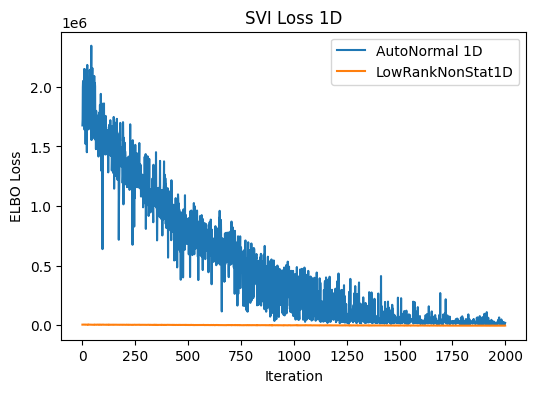

Step: 100 ELBO: 557464.562
Step: 200 ELBO: 731691.188
Step: 300 ELBO: 544596.438
Step: 400 ELBO: 506104.250
Step: 500 ELBO: 326445.594
Step: 600 ELBO: 341307.656
Step: 700 ELBO: 245553.547
Step: 800 ELBO: 276219.156
Step: 900 ELBO: 210783.797
Step: 1000 ELBO: 204969.469
Step: 1100 ELBO: 189382.781
Step: 1200 ELBO: 186141.359
Step: 1300 ELBO: 212462.797
Step: 1400 ELBO: 167504.125
Step: 1500 ELBO: 202891.969
Step: 1600 ELBO: 152828.594
Step: 1700 ELBO: 145276.422
Step: 1800 ELBO: 155495.297
Step: 1900 ELBO: 141054.016
Step: 2000 ELBO: 134416.734
Step: 100 ELBO: 175491.453
Step: 200 ELBO: 166972.812
Step: 300 ELBO: 148543.062
Step: 400 ELBO: 151716.344
Step: 500 ELBO: 154106.109
Step: 600 ELBO: 125785.516
Step: 700 ELBO: 117835.906
Step: 800 ELBO: 125719.320
Step: 900 ELBO: 119112.102
Step: 1000 ELBO: 118733.008
Step: 1100 ELBO: 113313.078
Step: 1200 ELBO: 110699.766
Step: 1300 ELBO: 107009.617
Step: 1400 ELBO: 112069.648
Step: 1500 ELBO: 110901.891
Step: 1600 ELBO: 103716.500
Step: 1700

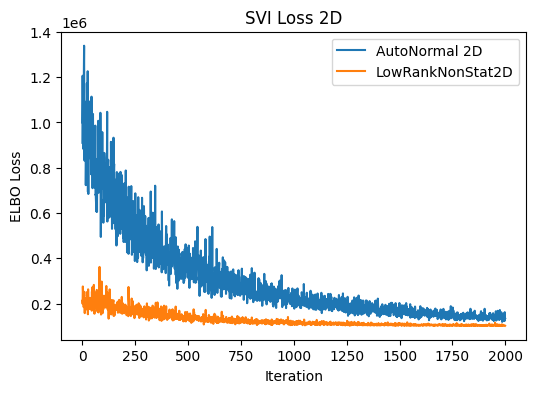

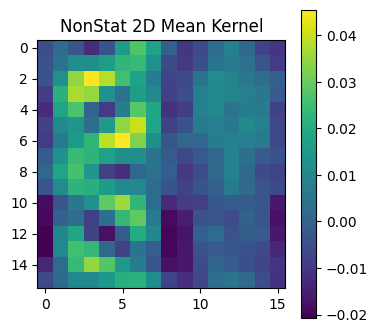

/var/folders/ch/74rww8ps6cx8x_ptd9fj5d400000gn/T/ipykernel_5633/764241619.py:164: RuntimeWarning: Mean of empty slice.
  radial_ns = [P2ns[:, (R>=bins[i]) & (R<bins[i+1])].mean() for i in range(len(bins)-1)]
/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


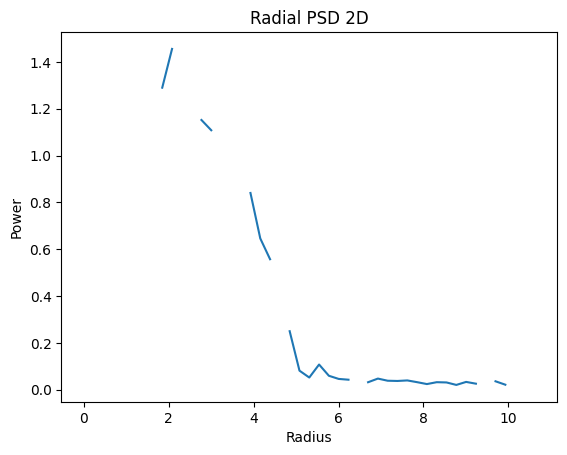

Completed both 1D & 2D non-stationary experiments.


In [15]:
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal, AutoGuideList
from numpyro.infer.initialization import init_to_feasible
from numpyro.handlers import block
import matplotlib.pyplot as plt

from quantbayes.bnn.guide.low_rank_fft_guide import LowRankNonStatFFTGuide

# ---------------------------------------------------------------------------
# 1D Non‑stationary experiment
# ---------------------------------------------------------------------------
def create_synthetic_dataset_1d(num_samples, D, true_kernel, noise_std=0.1, seed=0):
    np.random.seed(seed)
    X = np.random.randn(num_samples, D)
    pad = D - true_kernel.shape[0]
    K_pad = np.pad(true_kernel, (0, pad))
    K_fft = np.fft.fft(K_pad)
    Y = np.fft.ifft(np.fft.fft(X, axis=-1) * K_fft[None, :], axis=-1).real
    Y += noise_std * np.random.randn(*Y.shape)
    return jnp.array(X), jnp.array(Y)

def gaussian_kernel_1d(size=9, sigma=2.0):
    x = np.linspace(-(size-1)/2., (size-1)/2., size)
    k = np.exp(-x**2/(2*sigma**2))
    return k / k.sum()

def conv1d_model(X, Y=None):
    layer = NonStatSpectralCirculantLayer(
        in_features=X.shape[-1], padded_dim=X.shape[-1],
        alpha_global=1.0, alpha_prior=dist.HalfNormal(1.0), name="ns1d"
    )
    preds = layer(X)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(preds, sigma).to_event(1), obs=Y)

# ---------------------------------------------------------------------------
# 2D Non‑stationary experiment
# ---------------------------------------------------------------------------
def create_synthetic_dataset_2d(num_samples, H, W, true_kernel, noise_std=0.1, seed=0):
    np.random.seed(seed)
    X = np.random.randn(num_samples, H, W)
    Kh, Kw = true_kernel.shape
    pad_h, pad_w = H - Kh, W - Kw
    K_pad = np.pad(true_kernel, ((0,pad_h),(0,pad_w)))
    K_fft = np.fft.fft2(K_pad)
    Y = np.fft.ifft2(np.fft.fft2(X, axes=(1,2)) * K_fft[None,:,:], axes=(1,2)).real
    Y += noise_std * np.random.randn(*Y.shape)
    return jnp.array(X), jnp.array(Y)

def conv2d_model(X, Y=None):
    layer = NonStatSpectralConv2d(
        H_in=X.shape[1], W_in=X.shape[2], H_pad=X.shape[1], W_pad=X.shape[2],
        alpha_global=1.0, alpha_coarse_shape=(8,8),
        alpha_prior=dist.HalfNormal(1.0), name="ns2d"
    )
    preds = layer(X)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(preds, sigma).to_event(2), obs=Y)

# ---------------------------------------------------------------------------
# SVI utility
# ---------------------------------------------------------------------------
def run_svi(model, guide, X, Y, steps=2000, lr=1e-3):
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    state = svi.init(jax.random.PRNGKey(0), X, Y)
    losses = []
    for i in range(steps):
        state, loss = svi.update(state, X, Y)
        losses.append(loss)
        if (i+1) % 100 == 0:
            print(f"Step: {i+1} ELBO: {loss:.3f}")
    return svi.get_params(state), np.array(losses)

# ---------------------------------------------------------------------------
# Main experiments
# ---------------------------------------------------------------------------
def main():
    # 1D Experiment
    D = 32
    k1 = gaussian_kernel_1d(9, 2.0)
    X1, Y1 = create_synthetic_dataset_1d(200, D, k1)
    X1_train, Y1_train = X1[:160], Y1[:160]
    X1_test,  Y1_test  = X1[160:], Y1[160:]

    guide1_auto = AutoNormal(conv1d_model)
    params1_a, loss1_a = run_svi(conv1d_model, guide1_auto, X1_train, Y1_train)

    guide1_ns = AutoGuideList(conv1d_model)
    guide1_ns.append(LowRankNonStat1DGuide(conv1d_model, prefix="ns1d", H_pad=None, W_pad=D, rank=8))
    guide1_ns.append(AutoNormal(block(conv1d_model, hide=["ns1d_delta_alpha","ns1d_real","ns1d_imag","obs"]), init_loc_fn=init_to_feasible))
    params1_ns, loss1_ns = run_svi(conv1d_model, guide1_ns, X1_train, Y1_train)

    plt.figure(figsize=(6,4))
    plt.plot(loss1_a, label="AutoNormal 1D")
    plt.plot(loss1_ns, label="LowRankNonStat1D")
    plt.xlabel("Iteration"); plt.ylabel("ELBO Loss"); plt.legend(); plt.title("SVI Loss 1D"); plt.show()

    # 2D Experiment
    H, W = 16, 16
    k2 = np.outer(np.hanning(9), np.hanning(9))
    X2, Y2 = create_synthetic_dataset_2d(200, H, W, k2)
    X2_train, Y2_train = X2[:160], Y2[:160]
    X2_test,  Y2_test  = X2[160:], Y2[160:]

    guide2_auto = AutoNormal(conv2d_model)
    params2_a, loss2_a = run_svi(conv2d_model, guide2_auto, X2_train, Y2_train)

    guide2_ns = AutoGuideList(conv2d_model)
    guide2_ns.append(LowRankNonStatFFTGuide(
        conv2d_model,
        prefix="ns2d",
        H_pad=H,
        W_pad=W,
        alpha_coarse_shape=(8,8),
        rank=8,
    ))
    guide2_ns.append(AutoNormal(
        block(conv2d_model, hide=[
            "ns2d_delta_alpha_map", "ns2d_real", "ns2d_imag", "obs"
        ]),
        init_loc_fn=init_to_feasible,
    ))
    params2_ns, loss2_ns = run_svi(conv2d_model, guide2_ns, X2_train, Y2_train)

    # Plot SVI losses
    plt.figure(figsize=(6,4))
    plt.plot(loss2_a, label="AutoNormal 2D")
    plt.plot(loss2_ns, label="LowRankNonStat2D")
    plt.xlabel("Iteration"); plt.ylabel("ELBO Loss"); plt.legend(); plt.title("SVI Loss 2D"); plt.show()

    # Posterior predictive kernels (2D)
    S = 50
    pred2_ns = Predictive(
        conv2d_model,
        guide=guide2_ns,
        params=params2_ns,
        num_samples=S,
        return_sites=["ns2d_real", "ns2d_imag", "ns2d_delta_alpha_map"],
    )
    s2_ns = pred2_ns(jax.random.PRNGKey(4), X2_train)
    fft2_ns = s2_ns["ns2d_real"] + 1j * s2_ns["ns2d_imag"]
    ker2_ns = np.fft.ifft2(fft2_ns, axes=(1,2)).real
    mean2_ns = ker2_ns.mean(0)

    plt.figure(figsize=(4,4))
    plt.imshow(mean2_ns, cmap='viridis')
    plt.title('NonStat 2D Mean Kernel')
    plt.colorbar(); plt.show()

    # Radial PSD 2D
    fx = np.fft.fftfreq(H)*H; fy = np.fft.fftfreq(W)*W
    U,V = np.meshgrid(fx, fy, indexing='ij')
    R = np.sqrt(U**2+V**2).flatten()
    P2ns = (np.abs(fft2_ns)**2).reshape(S, -1)
    bins = np.linspace(0, R.max(), 50)
    radial_ns = [P2ns[:, (R>=bins[i]) & (R<bins[i+1])].mean() for i in range(len(bins)-1)]
    plt.figure();
    plt.plot(bins[:-1], radial_ns, label='NonStat2D');
    plt.xlabel('Radius'); plt.ylabel('Power'); plt.title('Radial PSD 2D'); plt.show()

    print("Completed both 1D & 2D non-stationary experiments.")

if __name__ == '__main__':
    main()

SVI step  200 ELBO 33647.30
SVI step  400 ELBO 23634.14
SVI step  600 ELBO 19596.57
SVI step  800 ELBO 8818.77
SVI step 1000 ELBO 2562.51


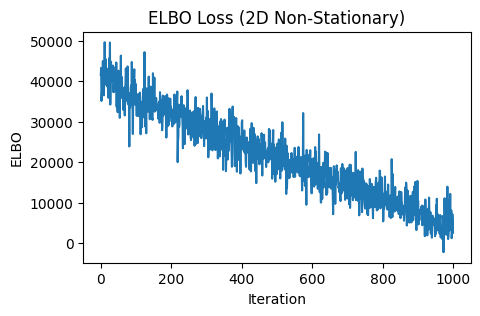

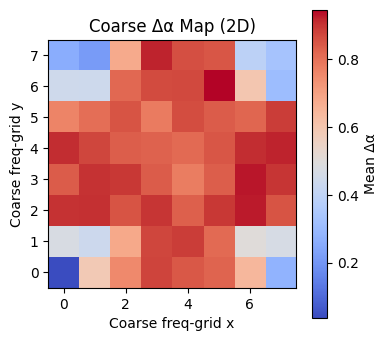

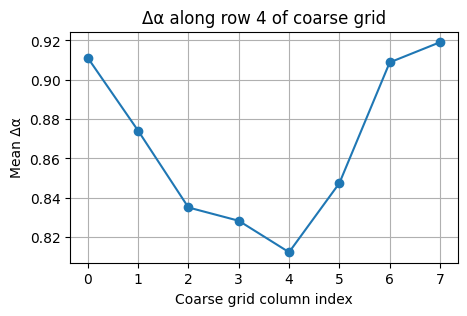

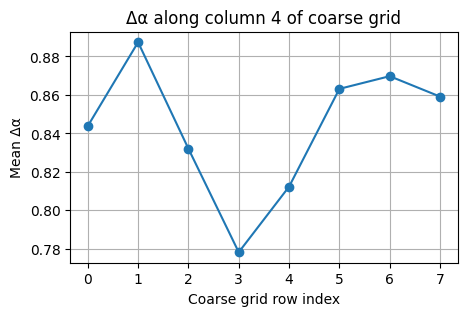

In [17]:
# ---------------------------------------------------------------------------
# 1) Synthetic 2D dataset
# ---------------------------------------------------------------------------
def create_synthetic_dataset_2d(num_samples, H, W, true_kernel, noise_std=0.1, seed=0):
    np.random.seed(seed)
    X = np.random.randn(num_samples, H, W)
    Kh, Kw = true_kernel.shape
    pad_h, pad_w = H - Kh, W - Kw
    K_pad = np.pad(true_kernel, ((0,pad_h),(0,pad_w)))
    K_fft = np.fft.fft2(K_pad)
    Y = np.fft.ifft2(np.fft.fft2(X, axes=(1,2)) * K_fft[None,:,:], axes=(1,2)).real
    Y += noise_std * np.random.randn(*Y.shape)
    return jnp.array(X), jnp.array(Y)

# simple 2D kernel, e.g. Hanning outer product
def hanning_kernel2d(size):
    w = np.hanning(size)
    K = np.outer(w, w)
    return K / K.sum()

# ---------------------------------------------------------------------------
# 2) Define model with NonStatSpectralConv2d
# ---------------------------------------------------------------------------
def conv2d_model(X, Y=None):
    N, H, W = X.shape
    layer = NonStatSpectralConv2d(
        H_in=H, W_in=W, H_pad=H, W_pad=W,
        alpha_global=1.0,
        alpha_coarse_shape=(8,8),
        alpha_prior=dist.HalfNormal(1.0),
        name="ns2d"
    )
    preds = layer(X)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(preds, sigma).to_event(2), obs=Y)

# ---------------------------------------------------------------------------
# 3) Prepare data and guide
# ---------------------------------------------------------------------------
H, W = 16, 16
true_k = hanning_kernel2d(9)
X2, Y2 = create_synthetic_dataset_2d(200, H, W, true_k)
X2_train, Y2_train = X2[:160], Y2[:160]

# AutoNormal for everything else
guide2_auto = AutoNormal(conv2d_model)

# Low‑rank nonstat guide for the spectral layer + AutoNormal for rest
guide2_ns = AutoGuideList(conv2d_model)
guide2_ns.append(
    LowRankNonStatFFTGuide(
        conv2d_model,
        prefix="ns2d",
        H_pad=H,
        W_pad=W,
        alpha_coarse_shape=(8,8),
        rank=8,
        jitter=1e-4
    )
)
guide2_ns.append(
    AutoNormal(
        block(conv2d_model,
              hide=["ns2d_delta_alpha_map","ns2d_real","ns2d_imag","obs"]),
        init_loc_fn=init_to_feasible
    )
)

# ---------------------------------------------------------------------------
# 4) Run SVI for 1000 steps
# ---------------------------------------------------------------------------
svi = SVI(conv2d_model, guide2_ns, Adam(1e-3), Trace_ELBO())
state = svi.init(jax.random.PRNGKey(0), X2_train, Y2_train)
losses = []
for i in range(1000):
    state, loss = svi.update(state, X2_train, Y2_train)
    losses.append(loss)
    if (i+1) % 200 == 0:
        print(f"SVI step {i+1:4d} ELBO {loss:.2f}")
params2_ns = svi.get_params(state)

plt.figure(figsize=(5,3))
plt.plot(losses)
plt.title("ELBO Loss (2D Non‑Stationary)")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.show()

# ---------------------------------------------------------------------------
# 5) Posterior predictive to get Δα‑map
# ---------------------------------------------------------------------------
S = 50
pred2_ns = Predictive(
    conv2d_model,
    guide=guide2_ns,
    params=params2_ns,
    num_samples=S,
    return_sites=["ns2d_delta_alpha_map"]
)
s2_ns = pred2_ns(jax.random.PRNGKey(1), X2_train)

# shape (S, gh, gw)
delta2 = np.array(s2_ns["ns2d_delta_alpha_map"])
mean_delta2 = delta2.mean(axis=0)
gh, gw = mean_delta2.shape

# ---------------------------------------------------------------------------
# 6) Visualize Δα in multiple directions
# ---------------------------------------------------------------------------
# a) Heatmap of the coarse Δα grid
plt.figure(figsize=(4,4))
plt.imshow(mean_delta2, cmap="coolwarm", origin="lower", interpolation="nearest")
plt.colorbar(label="Mean Δα")
plt.title("Coarse Δα Map (2D)")
plt.xlabel("Coarse freq‐grid x")
plt.ylabel("Coarse freq‐grid y")
plt.show()

# b) Horizontal slice through middle of the map
mid_row = gh // 2
plt.figure(figsize=(5,3))
plt.plot(np.arange(gw), mean_delta2[mid_row, :], marker="o")
plt.title(f"Δα along row {mid_row} of coarse grid")
plt.xlabel("Coarse grid column index")
plt.ylabel("Mean Δα")
plt.grid(True)
plt.show()

# c) Vertical slice through middle of the map
mid_col = gw // 2
plt.figure(figsize=(5,3))
plt.plot(np.arange(gh), mean_delta2[:, mid_col], marker="o")
plt.title(f"Δα along column {mid_col} of coarse grid")
plt.xlabel("Coarse grid row index")
plt.ylabel("Mean Δα")
plt.grid(True)
plt.show()

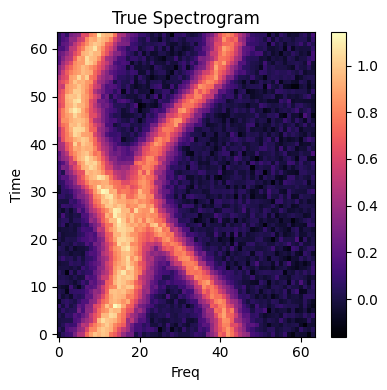

[500] ELBO = -22807.758
[1000] ELBO = -12485.762
[1500] ELBO = -7395.870
[2000] ELBO = -7070.906
[2500] ELBO = -6467.256
[3000] ELBO = -5963.005


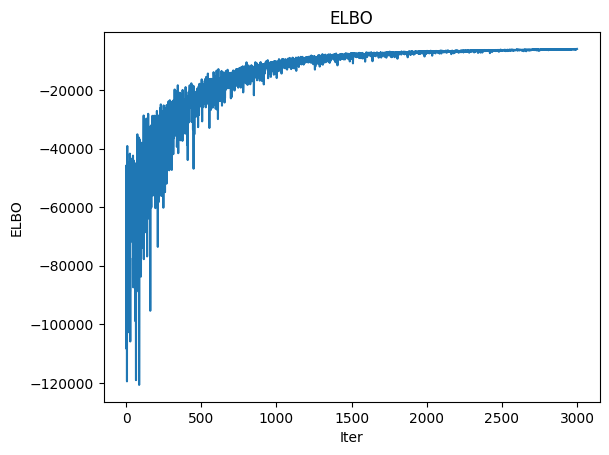

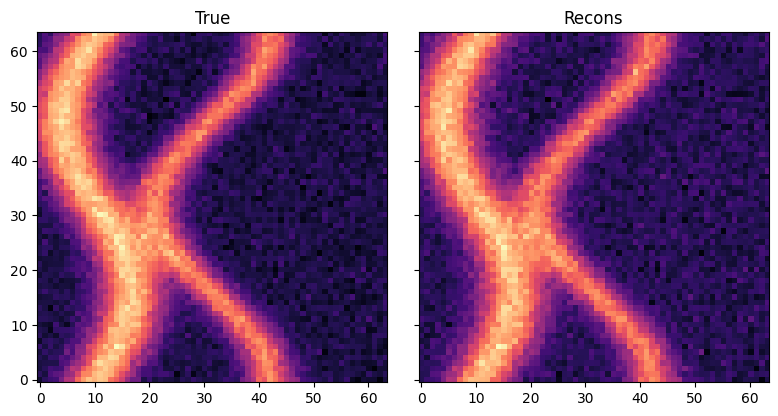

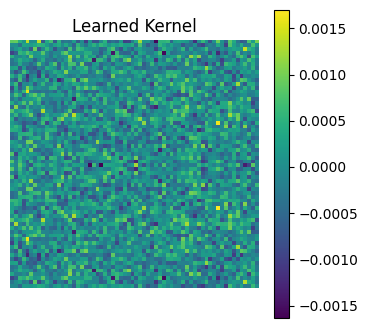

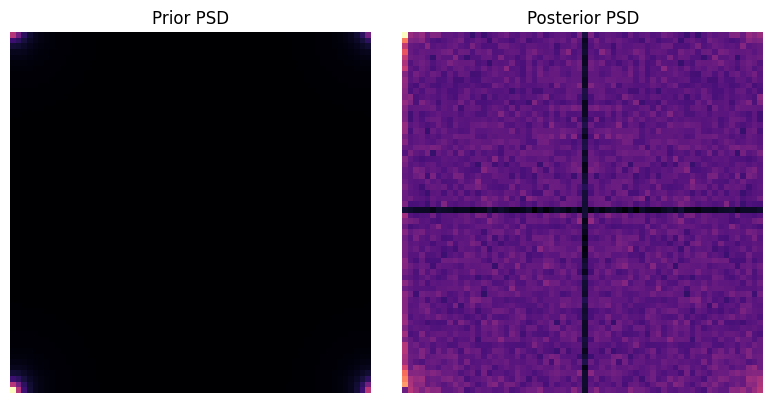

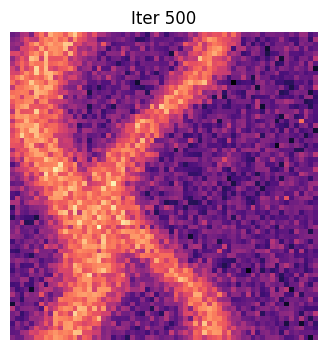

In [25]:
import jax, jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoGuideList, AutoNormal

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from quantbayes.bnn.layers import SpectralPowerLawConv2d
from quantbayes.bnn.guide import LowRankFFTGuide

# 0) Synthetic spectrogram
def make_synthetic_spectrogram(H=64, W=64):
    x = np.linspace(0, 1, H).reshape(-1, 1)
    y = np.linspace(0, 1, W).reshape(1, -1)
    freq1 = 5 + 3 * np.sin(2*np.pi*x)
    freq2 = 15 + 5 * np.cos(2*np.pi*x)
    omega = y * 30.0
    band1 = np.exp(-0.5*((omega - freq1)**2)/2.0**2)
    band2 = np.exp(-0.5*((omega - freq2)**2)/1.5**2)
    spec = band1 + 0.8*band2 + 0.05*np.random.randn(H, W)
    return spec

Y = make_synthetic_spectrogram(64,64)
X = jnp.zeros_like(Y)  # dummy input
H, W = Y.shape

# plot ground truth
plt.figure(figsize=(4,4))
plt.imshow(Y, origin='lower', cmap='magma', aspect='auto')
plt.title("True Spectrogram"); plt.xlabel("Freq"); plt.ylabel("Time")
plt.colorbar(); plt.tight_layout(); plt.show()

# 1) Model
def conv_regression_model(X, Y=None):
    conv = SpectralPowerLawConv2d(H, W, H_pad=H, W_pad=W, name="mix")
    preds = conv(X)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    numpyro.sample("obs",
                   dist.Normal(preds, sigma).to_event(2),
                   obs=Y)

# 2) Guide
guide = AutoGuideList(conv_regression_model)
guide.append(
    LowRankFFTGuide(conv_regression_model, prefix="mix",
                    H_pad=H, W_pad=W, rank=8)
)
guide.append(
    AutoNormal(numpyro.handlers.block(
        conv_regression_model,
        hide=["mix_real","mix_imag"]
    ), init_loc_fn=numpyro.infer.init_to_feasible)
)

# 3) SVI with snapshots
svi = SVI(conv_regression_model, guide, Adam(1e-3), Trace_ELBO())
state = svi.init(jax.random.PRNGKey(0), X[None], Y[None])

losses = []
snapshots = []
for i in range(1, 3001):
    state, loss = svi.update(state, X[None], Y[None])
    losses.append(loss)
    if i % 500 == 0:
        print(f"[{i}] ELBO = {-loss:.3f}")
        # record reconstruction
        params = svi.get_params(state)
        pred_mean = Predictive(
            conv_regression_model,
            guide=guide,
            params=params,
            num_samples=50
        )(jax.random.PRNGKey(i), X[None])[ "obs" ].mean(0)[0]
        snapshots.append((i, np.array(pred_mean)))

# plot ELBO
plt.figure()
plt.plot(-np.array(losses))
plt.title("ELBO"); plt.xlabel("Iter"); plt.ylabel("ELBO"); plt.show()

# 4) Final recon
params = svi.get_params(state)
post = Predictive(
    conv_regression_model,
    guide=guide,
    params=params,
    num_samples=200
)(jax.random.PRNGKey(42), X[None])

pred_final = post["obs"].mean(0)[0]
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4),sharey=True)
ax1.imshow(Y, origin='lower', cmap='magma'); ax1.set_title("True")
ax2.imshow(pred_final, origin='lower', cmap='magma'); ax2.set_title("Recons")
plt.tight_layout(); plt.show()

# 5) Learned kernel
post_k = Predictive(
    conv_regression_model,
    guide=guide,
    params=params,
    num_samples=200,
    return_sites=["mix_real","mix_imag"]
)(jax.random.PRNGKey(1), X[None])

real = post_k["mix_real"]  # (S,H,W)
imag = post_k["mix_imag"]
F_mean = jnp.mean(real + 1j * imag, axis=0)
K = jnp.fft.ifft2(F_mean).real

plt.figure(figsize=(4,4))
plt.imshow(np.array(K), cmap="viridis")
plt.title("Learned Kernel"); plt.axis("off"); plt.colorbar(); plt.show()

# 6) Prior vs Posterior PSD
u = np.fft.fftfreq(H)*H; v = np.fft.fftfreq(W)*W
U,V = np.meshgrid(u,v,indexing="ij"); R = np.sqrt(U**2+V**2)
# posterior PSD: E[|F|^2]
PSD_post = np.mean(np.abs(np.array(real + 1j*imag))**2, axis=0)
# approximate posterior α if you sampled it
alpha_post = post.get("mix_alpha", jnp.array([2.0]))  
alpha_est = float(alpha_post.mean())
PSD_prior = 1.0/(1.0 + R**alpha_est)

fig,(p1,p2)=plt.subplots(1,2,figsize=(8,4))
p1.imshow(PSD_prior, origin='lower', cmap='magma'); p1.set_title("Prior PSD"); p1.axis("off")
p2.imshow(PSD_post, origin='lower', cmap='magma'); p2.set_title("Posterior PSD"); p2.axis("off")
plt.tight_layout(); plt.show()

# 7) Animation
fig = plt.figure(figsize=(4,4))
im = plt.imshow(snapshots[0][1], origin='lower', cmap='magma')
plt.axis("off")
def update(frame):
    it, frame_data = snapshots[frame]
    im.set_data(frame_data)
    plt.title(f"Iter {it}")
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=len(snapshots),
                              blit=True, interval=500)
# In Jupyter: from IPython.display import HTML; HTML(ani.to_jshtml())
# Or save: ani.save("recon.gif", writer="imagemagick")


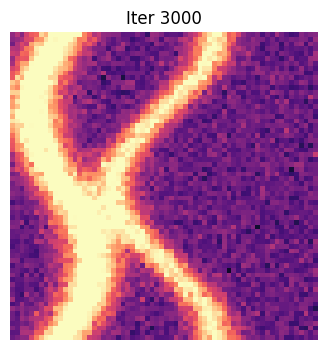

In [26]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- assumes `snapshots` is a list of (iter, frame_array) as above ---

fig = plt.figure(figsize=(4,4))
im = plt.imshow(snapshots[0][1], origin='lower', cmap='magma')
plt.axis("off")

def update(frame_idx):
    it, frame = snapshots[frame_idx]
    im.set_data(frame)
    plt.title(f"Iter {it}")
    return (im,)

ani = animation.FuncAnimation(
    fig, update,
    frames=len(snapshots),
    blit=True,
    interval=500  # ms between frames
)

# Display inline in Jupyter
HTML(ani.to_jshtml())


## Spectral Variational Auto Encoder and score based diffusion 

In [3]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_feasible

import optax
import arviz as az
import matplotlib.pyplot as plt

from quantbayes.fake_data import generate_regression_data
from quantbayes.bnn import SpectralCirculantLayer, Linear

# 1. Generate synthetic data
df = generate_regression_data(n_continuous=16)
X, y = df.drop("target", axis=1).values, df["target"].values

# 2. Define both models
def Dense_Model(X, y=None):
    N, D = X.shape
    X_latent = Linear(D, D)(X)
    X_latent = jax.nn.tanh(X_latent)
    mu = Linear(D, 1, name="out")(X_latent).squeeze(-1)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

def SpectralCirculant_Model(X, y=None):
    N, D = X.shape
    X_latent = SpectralCirculantLayer(D)(X)
    X_latent = jax.nn.tanh(X_latent)
    mu = Linear(D, 1, name="out")(X_latent).squeeze(-1)
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

# 3. SVI fitting function
def fit_svi(model, X, y, rng_key, num_iters=5000, lr=1e-3):
    guide = AutoNormal(model, init_loc_fn=init_to_feasible)
    optimizer = optax.adam(lr)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
    state = svi.init(rng_key, X, y)
    elbo_hist = []
    for i in range(num_iters):
        state, elbo = svi.update(state, X, y)
        if i % 100 == 0:
            elbo_hist.append(elbo)
    params = svi.get_params(state)
    predictive = Predictive(guide, params=params, num_samples=2000)
    svi_samples = predictive(rng_key, X, y=None)
    return np.array(elbo_hist), svi_samples

# 4. MCMC fitting function
def fit_mcmc(model, X, y, rng_key, num_warmup=1000, num_samples=2000):
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
    mcmc.run(rng_key, X, y)
    return mcmc

key = jr.key(0)
dense_mcmc = fit_mcmc(Dense_Model, X, y, key)
spectral_mcmc = fit_mcmc(SpectralCirculant_Model, X, y, key)

sample: 100%|██████████| 3000/3000 [05:29<00:00,  9.09it/s, 1023 steps of size 2.68e-03. acc. prob=0.94]


In [2]:
#!/usr/bin/env python3
"""
experiments/spectral_fft_expts.py

Run SVI experiments comparing:
  - AutoMultivariateNormal
  - AutoLowRankMultivariateNormal
  - Custom LowRank1DFFTGuide

on a toy 1D regression task with a known spectral filter,
and produce the key plots for your paper.
"""

import math
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, init_to_feasible
from numpyro.infer.autoguide import (
    AutoMultivariateNormal,
    AutoLowRankMultivariateNormal,
    AutoGuideList,
    AutoNormal,
)
from numpyro.optim import Adam
import arviz as az

# ------------------------------------------------------------------
from quantbayes.bnn.guide.low_rank_fft_guide import LowRank1DFFTGuide
from quantbayes.bnn import SpectralCirculantLayer
# ------------------------------------------------------------------

def generate_toy_data(key, N=200, D=16, alpha_true=2.0, noise_std=0.1):
    freqs = jnp.arange(D // 2 + 1)
    psd = 1.0 / jnp.sqrt(1 + freqs**alpha_true)
    kernel_true = jnp.fft.irfft(psd, n=D)

    key, subkey = jax.random.split(key)
    X = jax.random.normal(subkey, (N, D))
    latent = jnp.tanh(jnp.dot(X, kernel_true))
    key, subkey = jax.random.split(key)
    y = latent + noise_std * jax.random.normal(subkey, (N,))

    # train/test split
    idx = np.arange(N)
    np.random.shuffle(idx)
    train_idx = idx[: int(0.8 * N)]
    test_idx  = idx[int(0.8 * N):]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx], kernel_true

def SpectralCirculant_Model(X, y=None):
    N, D = X.shape
    # single spectral layer, pad=D, full K
    X_latent = SpectralCirculantLayer(D, padded_dim=D)(X)
    X_latent = jnp.tanh(X_latent)
    # simple linear head
    w = numpyro.sample("lin_w", dist.Normal(0,1).expand([D]).to_event(1))
    b = numpyro.sample("lin_b", dist.Normal(0,1))
    mu = jnp.dot(X_latent, w) + b
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

def run_svi(model, guide, X, y, num_steps=2000, lr=1e-2, rng_key=None):
    if rng_key is None:
        rng_key = jax.random.PRNGKey(0)
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    state = svi.init(rng_key, X, y)
    elbo = []
    for i in range(num_steps):
        state, loss = svi.update(state, X, y)
        elbo.append(-loss)
        if (i+1) % 500 == 0:
            print(f"Step: [{i+1}/{num_steps}] ELBO: {-loss:.3f}")
    params = svi.get_params(state)
    return np.array(elbo), params

def plot_elbo(elbo_dict):
    plt.figure(figsize=(6,4))
    for name, elbo in elbo_dict.items():
        plt.plot(elbo, label=name)
    plt.xlabel("SVI step")
    plt.ylabel("ELBO")
    plt.legend()
    plt.tight_layout()
    plt.savefig("elbo_comparison.png")
    plt.close()

def compute_rmse(model, guide, params, X_test, y_test, rng_key, num_samples=500):
    predictive = Predictive(model, guide=guide, params=params, num_samples=num_samples)
    samples = predictive(rng_key, X_test, None)["obs"]  # shape (num_samples, N_test)
    mu = samples.mean(axis=0)
    return float(jnp.sqrt(jnp.mean((mu - y_test) ** 2)))


def plot_filter_recovery(kernel_true, samples_real, samples_imag, D, outname):
    # reconstruct full FFT & impulse responses
    def build_full(real_hp, imag_hp):
        half = real_hp + 1j * imag_hp
        if D % 2 == 0:
            nyq = half[-1: ]
            fft_full = jnp.concatenate([half[:-1], nyq, jnp.conj(half[1:-1])[::-1]])
        else:
            fft_full = jnp.concatenate([half, jnp.conj(half[1:])[::-1]])
        return jnp.fft.ifft(fft_full).real

    ir_samps = jax.vmap(build_full)(samples_real, samples_imag)
    ir_mean  = ir_samps.mean(axis=0)
    ir_lo    = jnp.percentile(ir_samps, 2.5, axis=0)
    ir_hi    = jnp.percentile(ir_samps, 97.5, axis=0)

    plt.figure(figsize=(6,4))
    plt.plot(kernel_true, '--k', label="True")
    plt.plot(ir_mean,    '-b', label="Posterior mean")
    plt.fill_between(np.arange(D), ir_lo, ir_hi, color='b', alpha=0.3)
    plt.xlabel("Index")
    plt.ylabel("Filter amplitude")
    plt.legend()
    plt.tight_layout()
    plt.savefig(outname)
    plt.close()

def plot_psd_recovery(samples_real, samples_imag, alpha_true, outname):
    D = (samples_real.shape[-1] - 1) * 2
    f = jnp.arange(D // 2 + 1)
    true_psd = 1.0 / jnp.sqrt(1 + f**alpha_true)
    post_psd = jnp.abs(samples_real + 1j * samples_imag).mean(axis=0)

    plt.figure(figsize=(6,4))
    plt.plot(f, true_psd, '--k', label="True PSD")
    plt.plot(f, post_psd, '-b',  label="Posterior mean PSD")
    plt.xlabel("Frequency")
    plt.ylabel("PSD")
    plt.legend()
    plt.tight_layout()
    plt.savefig(outname)
    plt.close()


def plot_ess(real_hp_samps, outname="ess_custom.png"):
    """
    real_hp_samps: array of shape (num_draws, k_half)
    """
    # Build an InferenceData with a single posterior variable
    idata = az.from_dict(posterior={"real_hp": np.array(real_hp_samps)})

    # Compute only the diagnostics (including ess_bulk and ess_tail)
    df = az.summary(idata, var_names=["real_hp"], kind="diagnostics")

    ess = df["ess_bulk"].values  # now this column will exist

    # Bar‐plot
    k_half = ess.shape[0]
    plt.figure(figsize=(6,3))
    plt.bar(np.arange(k_half), ess)
    plt.xlabel("Frequency index")
    plt.ylabel("Bulk ESS")
    plt.title("Effective sample size per freq (custom)")
    plt.tight_layout()
    plt.savefig(outname)
    plt.close()


def main():
    rng_key = jax.random.PRNGKey(0)
    X_tr, y_tr, X_te, y_te, kernel_true = generate_toy_data(rng_key)

    # ------------------
    # Setup guides
    # ------------------
    guide_mvn = AutoMultivariateNormal(SpectralCirculant_Model)
    guide_lr  = AutoLowRankMultivariateNormal(SpectralCirculant_Model, rank=8)

    guide_custom = AutoGuideList(SpectralCirculant_Model)
    guide_custom.append(
        LowRank1DFFTGuide(
            SpectralCirculant_Model,
            prefix="spectral_circ_jvp",
            padded_dim=X_tr.shape[1],
            rank=8,
            jitter=1e-4,
        )
    )
    guide_custom.append(
        AutoNormal(
            numpyro.handlers.block(
                SpectralCirculant_Model,
                hide=["spectral_circ_jvp_real", "spectral_circ_jvp_imag"],
            ),
            init_loc_fn=init_to_feasible,
        )
    )

    # ------------------
    # Run SVI
    # ------------------
    print("Running SVI AutoMVN...")
    elbo_mvn, params_mvn = run_svi(SpectralCirculant_Model, guide_mvn, X_tr, y_tr, rng_key=rng_key)
    print("Running SVI AutoLowRankMVN...")
    elbo_lr,  params_lr  = run_svi(SpectralCirculant_Model, guide_lr,  X_tr, y_tr, rng_key=rng_key)
    print("Running SVI LowRankFFTGuide...")
    elbo_cu,  params_cu  = run_svi(SpectralCirculant_Model, guide_custom, X_tr, y_tr, rng_key=rng_key)

    # plot ELBO
    plot_elbo({
        "AutoMVN": elbo_mvn,
        "AutoLowRankMVN": elbo_lr,
        "LowRankFFTGuide": elbo_cu
    })

    # compute and print RMSE on test set
    rmse_mvn = compute_rmse(SpectralCirculant_Model, guide_mvn, params_mvn, X_te, y_te, rng_key)
    rmse_lr  = compute_rmse(SpectralCirculant_Model, guide_lr,  params_lr,  X_te, y_te, rng_key)
    rmse_cu  = compute_rmse(SpectralCirculant_Model, guide_custom, params_cu, X_te, y_te, rng_key)
    print(f"\nTest RMSE:\n  AutoMVN: {rmse_mvn:.4f}\n  AutoLowRankMVN: {rmse_lr:.4f}\n  LowRankFFTGuide: {rmse_cu:.4f}")


    # ------------------
    # Posterior recovery plots (custom guide)
    # ------------------
    pred = Predictive(
        SpectralCirculant_Model,
        guide=guide_custom,
        params=params_cu,
        num_samples=500,
        return_sites=["spectral_circ_jvp_real", "spectral_circ_jvp_imag"]
    )
    samples = pred(rng_key, X_tr, None)
    real_hp = samples["spectral_circ_jvp_real"]
    imag_hp = samples["spectral_circ_jvp_imag"]
    D = X_tr.shape[1]

    plot_filter_recovery(kernel_true, real_hp, imag_hp, D, "filter_recovery.png")
    plot_psd_recovery(real_hp, imag_hp, alpha_true=2.0, outname="psd_recovery.png")
    plot_ess(real_hp, outname="ess_custom.png")


if __name__ == "__main__":
    main()


Running SVI AutoMVN...
Step: [500/2000] ELBO: -127.312
Step: [1000/2000] ELBO: -31.773
Step: [1500/2000] ELBO: -20.422
Step: [2000/2000] ELBO: -33.959
Running SVI AutoLowRankMVN...
Step: [500/2000] ELBO: -164.528
Step: [1000/2000] ELBO: -34.132
Step: [1500/2000] ELBO: -30.070
Step: [2000/2000] ELBO: -5.508
Running SVI LowRankFFTGuide...
Step: [500/2000] ELBO: -17.563
Step: [1000/2000] ELBO: -111.489
Step: [1500/2000] ELBO: 7.322
Step: [2000/2000] ELBO: 4.979

Test RMSE:
  AutoMVN: 0.1271
  AutoLowRankMVN: 0.1050
  LowRankFFTGuide: 0.1147


/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (500) than draws (9). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
